# 02. EDA — 창원국가산단 업종별 산업·고용 전환진단

**본분석은 KICOX 명목 생산액과 고용의 전년동기 대비 변화 방향을 사용한다.**
PPI는 선택한 전국 가격지수를 적용했을 때 생산 방향이 달라지는지 확인하는 보조분석이다.
PPI 조정값으로 본분석 국면을 대체하지 않는다.

| 질문 | 확인할 내용 | 위치 |
|---|---|---|
| Q1 상태 | 같은 고용 변화에서도 명목 생산 방향이 다른가? | Section 2 |
| Q2 규모 | 제조업 고용 변화에서 인원 변화가 큰 업종은 어디인가? | Section 3 |
| Q3 시간 | 국면이 얼마나 이어지고 어떤 경로로 바뀌는가? | Section 4 |

가동률·업체수는 Section 5, PPI·EIS는 Section 6의 보조자료다. 국면은 좋고 나쁨의 평가가 아니다.

### 입력 및 실행

프로젝트 루트 또는 `notebooks`에서 실행한다. 계산에 필요한 입력은 아래 경로에 둔다.

- `data/processed/kicox/changwon_state_panel.csv`
- `data/processed/kicox/changwon_total_master.csv`
- `data/raw/ppi/ppi_raw.csv`
- `data/raw/eis/eis_changwon_insured_2022M03_2026M06.csv` 또는 기존 EIS 검증 패널

이 수정본은 이전에 공유된 KICOX 패널과 PPI 원자료로 실행했다. 사용자 PC의 최신 파일과 동일한지는 확인하지 못했다.
원래 매핑 CSV가 없어 기존 노트북의 매핑 출력에서 후보 항목을 확인한 뒤 원자료 코드로 재구성했다.
자료 보정·창원상의 교차검증·결측 보완의 별도 CSV는 확보하지 못해 해당 결과를 검증 완료로 취급하지 않는다.
원본 패널의 YoY·국면·지속·전환 값은 검산하고 유지한다. 결과는 코드에서 계산해 표·설명·요약에 재사용한다.

## Section 0. 공통 분석 기준 · 데이터 점검

In [1]:
import warnings
import json
import hashlib
from IPython.display import display, Markdown
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.lines import Line2D

warnings.filterwarnings('ignore', message='This figure includes Axes')

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'data' / 'processed' / 'kicox' / 'changwon_state_panel.csv').is_file()), None)
if ROOT is None:
    raise FileNotFoundError('프로젝트의 data/processed/kicox/changwon_state_panel.csv가 필요합니다.')
DIR_PROC = ROOT / 'data' / 'processed'
DIR_FIG = ROOT / 'outputs' / 'figures'
DIR_TAB = ROOT / 'outputs' / 'tables'
DIR_REPORT = ROOT / 'outputs' / 'report'
DIR_FIG.mkdir(parents=True, exist_ok=True)
DIR_TAB.mkdir(parents=True, exist_ok=True)
DIR_REPORT.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------------- 한글 폰트
# 실행 환경(Windows / macOS / Linux)에 따라 설치된 한글 폰트가 다르므로 사용 가능한 첫 폰트를 쓴다.
import matplotlib.font_manager as fm
for _font in Path('/usr/local/share/fonts').glob('*.ttf'):
    fm.fontManager.addfont(str(_font))
_installed = {f.name for f in fm.fontManager.ttflist}
for _cand in ['Malgun Gothic', 'AppleGothic', 'NanumGothic',
              'Noto Sans CJK KR', 'Noto Sans CJK JP', 'DejaVu Sans']:
    if _cand in _installed:
        plt.rcParams['font.family'] = [_cand, 'sans-serif']
        break
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = False
plt.rcParams['font.size'] = 10

# ---------------------------------------------------------------- 배색 규칙
# 1) 국면 배색 — 좋음/나쁨의 신호등 연상을 줄인 청·청록·황·보라의 범주형 배색.
#    국면은 평가가 아닌 상태 분류이며, 노트북 전체가 이 딕셔너리 하나만 참조한다.
STATE_COLORS = {'S1': '#4C78A8', 'S2': '#72B7B2', 'S3': '#F2CF5B', 'S4': '#B279A2',
                'N': '#BDBDBD', 'INVALID': '#F2F2F2'}
STATE_LABELS = {'S1': 'S1 생산↑·고용↑', 'S2': 'S2 생산↑·고용↓',
                'S3': 'S3 생산↓·고용↑', 'S4': 'S4 생산↓·고용↓',
                'N': 'N 한 지표 이상 변화 0%', 'INVALID': 'INVALID 계산불가(결측)'}
STATES4 = ['S1', 'S2', 'S3', 'S4']
STATES5 = ['S1', 'S2', 'S3', 'S4', 'N']
STATES6 = ['S1', 'S2', 'S3', 'S4', 'N', 'INVALID']

# 2) 증감 방향 배색(Q2 전용) — 국면 배색과 의미가 겹치지 않도록 별도 색을 쓴다.
DELTA_COLORS = {'down': '#B4485F', 'up': '#3F6FA8', 'neutral': '#BFBFBF'}

# 3) 생산/고용 지표 배색 — 선 그래프에서 두 지표를 구분하는 고정 규칙.
SERIES_COLORS = {'production': '#2F5C8F', 'employment': '#9C5C86'}

# 4) 업종 배색(Q2-B 전용) — 주요 업종 + 나머지 합계. 색 수를 5개로 제한한다.
MAIN_COLORS = ['#2F4B7C', '#6A8EAE', '#A9BED0', '#4E6E5D']
REST_COLOR = '#C9C9C9'

# ---------------------------------------------------------------- 데이터 적재
state = pd.read_csv(DIR_PROC / 'kicox' / 'changwon_state_panel.csv')
total = pd.read_csv(DIR_PROC / 'kicox' / 'changwon_total_master.csv')
state.columns = [c.lstrip('﻿') for c in state.columns]
total.columns = [c.lstrip('﻿') for c in total.columns]
state = state.sort_values(['industry', 'quarter_index']).reset_index(drop=True)

# ---------------------------------------------------------------- 공통 기준(고정)
QUARTERS = sorted(state.quarter.unique())          # 분석기간: 본분석 패널 그대로
LATEST = QUARTERS[-1]                              # 최신분기(현재 국면 판정 기준)
PREV = QUARTERS[-2]                                # 직전분기
BASE_Q = str(pd.Period(LATEST, freq='Q') - 4)                              # 최신분기의 전년동기(YoY 비교 기준분기)
INDUSTRIES = sorted(state.industry.unique())       # 10개 업종 정의: 전처리 산출물 그대로
INVALID_QUARTERS = sorted(state.loc[state.state == 'INVALID', 'quarter'].unique())
THRESHOLD = state.threshold.iloc[0]                # 중립구간 기준(본분석 = 0)

# 최신분기 고용비중 내림차순 — 모든 그림·표의 기본 업종 정렬 기준
IND_ORDER_EMP = (state[state.quarter == LATEST]
                 .sort_values('employment', ascending=False).industry.tolist())

# ---------------------------------------------------------------- 표현용 집계
# 고용 증감 '인원'은 01 산출물에 없어 여기서 파생한다. employment_yoy(01 산출물)와 동일한
# lag4 정의를 쓰며, 기간 절단 전 확보된 전년동기 값을 사용한다.
state['employment_lag4_lvl'] = state.employment_lag4
state['emp_delta'] = state.employment - state.employment_lag4_lvl
state['production_lag4_lvl'] = state.production_lag4

# 제조업 전체 = 10개 업종 합계(Section 0 가산성 검증 참조)
mfg = (state.groupby('quarter')
       .agg(mfg_employment=('employment', 'sum'),
            mfg_emp_delta=('emp_delta', 'sum'),
            mfg_emp_gross=('emp_delta', lambda s: s.abs().sum()),
            n_delta=('emp_delta', 'count'))
       .reindex(QUARTERS))
mfg.loc[mfg.n_delta < len(INDUSTRIES), ['mfg_emp_delta', 'mfg_emp_gross']] = np.nan
# 순변화/총변화 비율 = |순증감| / |업종별 증감|합. 1에 가까우면 같은 방향, 0에 가까우면 상쇄가 크다.
mfg['net_gross_ratio'] = mfg.mfg_emp_delta.abs() / mfg.mfg_emp_gross
# 기여율(%)은 분모(순증감)가 작으면 값이 과도해지므로 아래 기준을 넘는 분기에만 사용한다.
SHARE_MIN_RATIO = 0.30
mfg['contrib_usable'] = mfg.net_gross_ratio >= SHARE_MIN_RATIO


# ---------------------------------------------------------------- 도우미 함수
def style_ax(ax, ygrid=True, xgrid=False):
    # 상단/우측 spine 제거 + grid 규칙 — 전 Figure 공통 레이아웃
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.22) if ygrid else None
    ax.grid(axis='x', alpha=0.22) if xgrid else None
    ax.set_axisbelow(True)
    return ax


def save_fig(fig, name):
    fig.savefig(DIR_FIG / f'{name}.png', dpi=300, bbox_inches='tight')


def n_fmt(v, unit='명'):
    # 증감 인원 표기: 부호 유지 + 천단위 구분
    if pd.isna(v):
        return '-'
    return f'{v:+,.0f}{unit}'


def bar_labels(ax, ys, values, fmt=lambda v: f'{v:+,.0f}', pad=None, fontsize=8.8):
    # 수평 bar 끝에 값 라벨 — 막대 방향에 따라 좌/우 정렬을 바꿔 겹침을 막는다
    span = max(abs(v) for v in values if not pd.isna(v)) or 1
    pad = pad if pad is not None else span * 0.02
    for y, v in zip(ys, values):
        if pd.isna(v):
            continue
        ha = 'left' if v >= 0 else 'right'
        ax.text(v + (pad if v >= 0 else -pad), y, fmt(v),
                va='center', ha=ha, fontsize=fontsize, color='#333333')


def place_labels(ax, xs, ys, texts, offsets=None, fontsize=9.3, min_gap_px=13, split_at=None):
    # 산점도 라벨을 점 오른쪽에 두고 화면좌표에서 세로 간격을 강제해 겹침을 없앤다.
    # split_at을 주면 그 값 위/아래 점의 라벨이 경계를 넘지 않도록 각각 바깥쪽으로 밀어낸다
    # (예: split_at=0이면 S1·S3 라벨은 0 위, S2·S4 라벨은 0 아래에 머문다).
    ax.figure.canvas.draw()
    trans = ax.transData
    inv = trans.inverted()
    pts = trans.transform(np.column_stack([xs, ys])).astype(float)
    offsets = np.zeros(len(xs)) if offsets is None else np.asarray(offsets, float)
    lab = pts.copy()
    if split_at is None:
        groups = [(np.arange(len(xs)), 'up')]
    else:
        y0 = trans.transform([[np.mean(xs), split_at]])[0, 1]
        groups = [(np.where(pts[:, 1] >= y0)[0], 'up'), (np.where(pts[:, 1] < y0)[0], 'down')]
    for idx, direction in groups:
        if len(idx) == 0:
            continue
        if direction == 'up':
            order = idx[np.argsort(pts[idx, 1])]
            yy = pts[order, 1].copy()
            for i in range(1, len(yy)):
                yy[i] = max(yy[i], yy[i - 1] + min_gap_px)
        else:
            order = idx[np.argsort(-pts[idx, 1])]
            yy = pts[order, 1].copy()
            for i in range(1, len(yy)):
                yy[i] = min(yy[i], yy[i - 1] - min_gap_px)
        lab[order, 1] = yy
    lab[:, 0] += offsets
    label_data = inv.transform(lab)
    for (lx, ly), (px, py), t in zip(label_data, np.column_stack([xs, ys]), texts):
        ax.annotate(t, xy=(px, py), xytext=(lx, ly), textcoords='data',
                    va='center', ha='left', fontsize=fontsize,
                    arrowprops=dict(arrowstyle='-', color='#B8B8B8', lw=0.7,
                                    shrinkA=0, shrinkB=3))


def state_path(ind, n=6, sep=' → '):
    # 업종별 최근 n분기 국면 경로 문자열(INVALID 포함, 관측 순서 그대로)
    g = state[state.industry == ind].sort_values('quarter_index').tail(n)
    return sep.join(g.state.tolist())


print(f'분석기간      : {QUARTERS[0]} ~ {LATEST} ({len(QUARTERS)}분기)')
print(f'최신분기      : {LATEST} (현재 국면 판정 기준)')
print(f'업종          : {len(INDUSTRIES)}개 — {", ".join(INDUSTRIES)}')
print(f'관측치        : {len(state)}행 (업종 x 분기)')
print(f'YoY 기준분기  : {LATEST}의 전년동기 = {BASE_Q}')
print(f'중립구간 기준 : threshold={THRESHOLD} (정확히 0%면 N, ±0.5/1/2%는 민감도 별도 패널)')
print(f'INVALID 분기  : {INVALID_QUARTERS}')
print(f'고용비중 정렬 : {" > ".join(IND_ORDER_EMP)}')

results_summary = {}
input_audit = []
def record_input(path, role):
    input_audit.append({'path': str(path.relative_to(ROOT)), 'role': role,
                        'sha256': hashlib.sha256(path.read_bytes()).hexdigest()})
for name in ['changwon_state_panel.csv', 'changwon_total_master.csv']:
    record_input(DIR_PROC / 'kicox' / name, '공유된 KICOX 입력')
assert not state.duplicated(['industry', 'quarter']).any(), '업종×분기 중복'
assert len(QUARTERS) == len(pd.period_range(QUARTERS[0], LATEST, freq='Q')), '분기 누락'
assert state.groupby('industry').size().eq(len(QUARTERS)).all(), '불균형 패널'
assert state.threshold.nunique() == 1 and THRESHOLD == 0, '본분석 중립기준 확인 필요'

def classify(p, e, threshold=0):
    if pd.isna(p) or pd.isna(e): return 'INVALID'
    if abs(p) <= threshold or abs(e) <= threshold: return 'N'
    return { (True, True): 'S1', (True, False): 'S2',
             (False, True): 'S3', (False, False): 'S4'}[(p > 0, e > 0)]

for variable in ['production', 'employment']:
    calc = (state[variable] / state[f'{variable}_lag4'] - 1) * 100
    calc = calc.where(state[f'{variable}_lag4'].ne(0))
    assert np.allclose(calc, state[f'{variable}_yoy'], equal_nan=True), f'{variable} YoY 불일치'
assert all(classify(r.production_yoy, r.employment_yoy) == r.state for r in state.itertuples()), '국면 불일치'
for ind, g in state.groupby('industry'):
    g = g.sort_values('quarter_index').reset_index(drop=True)
    expected_next = g.state.shift(-1)
    valid_next = g.state.isin(STATES5) & expected_next.isin(STATES5)
    assert np.array_equal(valid_next, g.valid_transition5), f'{ind}: 인접 전환 불일치'
    assert g.loc[valid_next, 'next_state'].eq(expected_next[valid_next]).all()
    start = 0
    for j in range(len(g)):
        if j == 0 or g.state[j] != g.state[j-1]: start = j
        if g.state[j] in STATES4:
            assert g.run_length[j] == j-start+1, f'{ind}: 연속분기 불일치'
    for _, block in g[g.state.isin(STATES4)].groupby('run_id'):
        assert block.run_total_length.eq(len(block)).all(), f'{ind}: 총 지속길이 불일치'
print('검산: 달력 분기, YoY, 국면, 연속기간, 인접 전환 일치')


def markdown_table(frame):
    # 표 렌더링을 위해 별도 패키지에 의존하지 않는다.
    f = frame.reset_index()
    cols = [str(x) for x in f.columns]
    rows = [[str(v).replace('|','/').replace('\n',' ') for v in row] for row in f.itertuples(index=False,name=None)]
    return '\n'.join(['| '+' | '.join(cols)+' |','| '+' | '.join(['---']*len(cols))+' |'] +
                      ['| '+' | '.join(row)+' |' for row in rows])


분석기간      : 2022Q1 ~ 2026Q2 (18분기)
최신분기      : 2026Q2 (현재 국면 판정 기준)
업종          : 10개 — 기계, 기타, 목재종이, 비금속, 석유화학, 섬유의복, 운송장비, 음식료, 전기전자, 철강
관측치        : 180행 (업종 x 분기)
YoY 기준분기  : 2026Q2의 전년동기 = 2025Q2
중립구간 기준 : threshold=0 (정확히 0%면 N, ±0.5/1/2%는 민감도 별도 패널)
INVALID 분기  : ['2023Q4', '2024Q4']
고용비중 정렬 : 기계 > 전기전자 > 운송장비 > 철강 > 음식료 > 석유화학 > 목재종이 > 비금속 > 기타 > 섬유의복
검산: 달력 분기, YoY, 국면, 연속기간, 인접 전환 일치


In [2]:
display(Markdown(f"""### 공통 분석 기준

- 분석기간: **{QUARTERS[0]}~{LATEST}**, {len(QUARTERS)}분기·{len(INDUSTRIES)}업종·{len(state)}행.
- 생산은 명목 금액, 고용은 인원이다. YoY는 전년동기 대비 변화율이다.
- 어느 한 지표라도 정확히 0%이면 N, 필요한 값이 없으면 INVALID다.
- 국면 계산 불가 분기: **{', '.join(INVALID_QUARTERS) or '없음'}**. 당분기 생산 미공표와 전년동기 값 부재를 구분한다.
- 고용 증감 인원은 `employment - employment_lag4`다. 본분석 시작 이전 전년동기 값도 사용한다.
- 제조업 전체는 이 패널의 **{len(INDUSTRIES)}개 업종 합계**로 정의한다.
"""))

### 공통 분석 기준

- 분석기간: **2022Q1~2026Q2**, 18분기·10업종·180행.
- 생산은 명목 금액, 고용은 인원이다. YoY는 전년동기 대비 변화율이다.
- 어느 한 지표라도 정확히 0%이면 N, 필요한 값이 없으면 INVALID다.
- 국면 계산 불가 분기: **2023Q4, 2024Q4**. 당분기 생산 미공표와 전년동기 값 부재를 구분한다.
- 고용 증감 인원은 `employment - employment_lag4`다. 본분석 시작 이전 전년동기 값도 사용한다.
- 제조업 전체는 이 패널의 **10개 업종 합계**로 정의한다.


In [3]:
display(state.state.value_counts().reindex(STATES6, fill_value=0).rename('관측 수').to_frame())
# 계산 불가 사유를 당분기 / 전년동기로 구분한다.
missing_summary = state.loc[state.state.eq('INVALID')].groupby('quarter').agg(
    관측수=('industry','size'), 당분기생산결측=('production_current_missing','sum'),
    전년동기생산결측=('production_lag4_missing','sum'))
display(missing_summary)
print('계산 불가 구간을 가로질러 같은 국면이 이어졌다고 연결하지 않는다.')

계산 불가 구간을 가로질러 같은 국면이 이어졌다고 연결하지 않는다.


,관측 수
state,
S1,54
S2,43
S3,13
S4,46
N,4
INVALID,20


,관측수,당분기생산결측,전년동기생산결측
quarter,,,
2023Q4,10,10,0
2024Q4,10,0,10


### 가산성 검증 — Q2에서 '기여도'라는 표현을 쓸 수 있는가

Q2는 "전체 고용 증감에서 업종별 변화가 차지하는 정도"를 다룬다. 이 표현이 성립하려면

**전체 고용 변화 = 10개 업종 고용 변화의 합**

이 실제 데이터에서 항등식으로 성립해야 한다. 아래에서 두 가지를 확인한다.

1. 10개 업종 합계가 `changwon_total_master.csv`의 산단 전체 값과 일치하는가
2. 일치하지 않는다면 무엇을 분모로 써야 하는가

In [4]:
agg = state.groupby('quarter')[['production', 'employment']].sum(min_count=1).reindex(QUARTERS)
chk = agg.join(total.set_index('quarter')[['production_total', 'employment_total']])
chk['생산_잔차'] = chk.production - chk.production_total
chk['고용_잔차'] = chk.employment - chk.employment_total
chk['고용_잔차_비율%'] = chk.고용_잔차 / chk.employment_total * 100
lag_mfg = state.groupby('quarter').employment_lag4.sum(min_count=len(INDUSTRIES)).reindex(QUARTERS)
_gap = (mfg.mfg_emp_delta - (agg.employment - lag_mfg)).abs().max()
assert _gap < 1e-6, '제조업 전체와 업종별 고용 증감 합 불일치'
results_summary['additivity'] = {'production_max_abs_gap': float(chk.생산_잔차.abs().max()),
    'employment_gap_latest': float(chk.loc[LATEST, '고용_잔차']), 'delta_identity_gap': float(_gap)}
display(chk[['생산_잔차','고용_잔차','고용_잔차_비율%']].round(4))
print(f'생산 합계 최대 절대차 {results_summary["additivity"]["production_max_abs_gap"]:.6f}억원.')
print('고용 총계와 업종 합계의 차이는 확인되지만, 차이의 구성은 이 파일만으로 확정하지 않는다.')

생산 합계 최대 절대차 0.000050억원.
고용 총계와 업종 합계의 차이는 확인되지만, 차이의 구성은 이 파일만으로 확정하지 않는다.


,생산_잔차,고용_잔차,고용_잔차_비율%
quarter,,,
2022Q1,-0.0000,-1503.0,-1.2652
2022Q2,-0.0000,-1512.0,-1.2775
2022Q3,-0.0000,-1549.0,-1.3214
2022Q4,-0.0000,-3682.0,-3.1737
2023Q1,-0.0000,-3717.0,-3.1650
2023Q2,0.0000,-3770.0,-3.2186
2023Q3,0.0000,-3717.0,-3.1714
2023Q4,NaN,-3686.0,-3.1451
2024Q1,0.0000,-3713.0,-3.1545


In [5]:
display(mfg[['mfg_emp_delta','mfg_emp_gross','net_gross_ratio','contrib_usable']].round(3))
print(f'순변화/총변화 비율 = |업종 합계 증감| / 업종별 증감 절대합. {SHARE_MIN_RATIO:.2f} 이상일 때만 기여율을 표시한다.')
print('이 기준은 분모가 작은 기여율의 오독을 줄이기 위한 표시 규칙이며 통계적 유의성 기준이 아니다.')

순변화/총변화 비율 = |업종 합계 증감| / 업종별 증감 절대합. 0.30 이상일 때만 기여율을 표시한다.
이 기준은 분모가 작은 기여율의 오독을 줄이기 위한 표시 규칙이며 통계적 유의성 기준이 아니다.


,mfg_emp_delta,mfg_emp_gross,net_gross_ratio,contrib_usable
quarter,,,,
2022Q1,280.0,5652.0,0.050,False
2022Q2,-70.0,5838.0,0.012,False
2022Q3,-266.0,4878.0,0.055,False
2022Q4,-3381.0,4597.0,0.735,True
2023Q1,-3571.0,9621.0,0.371,True
2023Q2,-3488.0,8118.0,0.430,True
2023Q3,-2191.0,8711.0,0.252,False
2023Q4,1178.0,9516.0,0.124,False
2024Q1,269.0,1073.0,0.251,False


In [6]:
display(Markdown(f"""### Q2의 집계 범위

{LATEST}에 업종 합계와 산단 고용 총계의 차이는 **{results_summary['additivity']['employment_gap_latest']:+,.0f}명**이다.
Q2는 업종 합계 안에서 고용 변화를 분해한다. 총계와의 차이를 특정 고용 유형이라고 단정하지 않는다.
"""))

### Q2의 집계 범위

2026Q2에 업종 합계와 산단 고용 총계의 차이는 **-4,851명**이다.
Q2는 업종 합계 안에서 고용 변화를 분해한다. 총계와의 차이를 특정 고용 유형이라고 단정하지 않는다.


### Section 0-2. 자료 보정 및 교차검증의 확인 범위

원공표와 연간 보정본을 섞어 전년동기를 비교하면 자료 수정이 증감률에 포함될 수 있다.
이번 실행에는 원자료별 수정폭 및 창원상의 교차검증 CSV가 없어 기존 수치를 재확인하지 못했다.
따라서 과거에 확인한 수정폭을 다른 분기의 최대 수정폭으로 사용하거나 실제 고용 이동을 입증한 것으로 해석하지 않는다.

In [7]:
optional_files = [
    ROOT/'outputs/tables/vintage_수정폭_실측.csv',
    ROOT/'outputs/tables/창원상의_교차검증.csv',
    ROOT/'outputs/tables/결측보완_2023Q4_2024Q4_국면.csv',
    DIR_PROC/'kicox/changwon_state_gapfill_panel.csv',
]
verification_scope = pd.DataFrame([{'파일': str(p.relative_to(ROOT)), '존재': p.is_file(),
    '이번수정본_처리': '기존 결과 미채택; 원자료 재검증 범위에서 제외'} for p in optional_files])
display(verification_scope)
# 존재 여부만 확인한다. 표 파일만으로 원공표-보정본 원자료 검증을 대신하지 않는다.
source_versions = state.groupby('quarter')[['production_source','employment_source']].first()
display(source_versions)

,파일,존재,이번수정본_처리
0,outputs/tables/vintage_수정폭_실측.csv,False,기존 결과 미채택; 원자료 재검증 범위에서 제외
1,outputs/tables/창원상의_교차검증.csv,False,기존 결과 미채택; 원자료 재검증 범위에서 제외
2,outputs/tables/결측보완_2023Q4_2024Q4_국면.csv,False,기존 결과 미채택; 원자료 재검증 범위에서 제외
3,data/processed/kicox/changwon_state_gapfill_pa...,False,기존 결과 미채택; 원자료 재검증 범위에서 제외


,production_source,employment_source
quarter,,
2022Q1,data_portal_monthly,data_portal_monthly
2022Q2,data_portal_monthly,data_portal_monthly
2022Q3,data_portal_monthly,data_portal_monthly
2022Q4,kicox_annual_revision,kicox_annual_revision
2023Q1,kicox_annual_revision,kicox_annual_revision
2023Q2,kicox_annual_revision,kicox_annual_revision
2023Q3,kicox_annual_revision,kicox_annual_revision
2023Q4,kicox_annual_revision,kicox_annual_revision
2024Q1,kicox_annual_revision,kicox_annual_revision


자료 개정 위험은 남아 있다. 그 위험을 이유로 관측값을 임의로 수정하지 않는다.
생산·고용이 변한 원인이 실제 사업장 변화인지 집계 변경인지는 현재 입력만으로 구분할 수 없다.

### 해석 범위

이번에 확인한 것은 제공된 패널 내부의 계산 일관성이다. 원공표·보정 원자료 사이의 재현 검증과는 구분한다.

### Section 0-3. 결측 보완값의 역할

당분기 생산액이 없거나 전년동기 생산액이 없으면 해당 YoY를 계산할 수 없다.
단지 총계를 업종에 배분한 추정치를 실제 공표값과 섞어 본분석 국면을 연결하지 않는다.

In [8]:
display(missing_summary)
print('결측 보완 패널과 배분 근거 파일이 없어 추정 국면·유지율을 재계산하지 않았다.')

결측 보완 패널과 배분 근거 파일이 없어 추정 국면·유지율을 재계산하지 않았다.


,관측수,당분기생산결측,전년동기생산결측
quarter,,,
2023Q4,10,10,0
2024Q4,10,0,10


실측치가 없는 구간은 그대로 비워 둔다. 결측 때문에 관측된 지속기간이 끊길 수 있다.
결측이 유지율을 높였는지 낮췄는지는 미관측 구간의 실제 국면을 알기 전에는 확정할 수 없다.

관측된 연속기간은 실제 지속기간 전체를 뜻하지 않는다. 패널 시작·끝 또는 결측 구간에 닿는 기간은
더 길게 이어졌을 수 있다. 특히 최근 국면은 아직 끝나지 않았으므로 완료된 기간으로 해석하지 않는다.

## Section 1. 배경 — 창원국가산단 전체 흐름과 업종 규모

Q1~Q3에 들어가기 전에 분석 대상의 크기와 장기 흐름만 확인한다. 이 절은 핵심 질문에 답하지 않는다.

2026Q2 기준 지수: 생산 115.6 / 고용 94.8
주의: production_total은 명목 생산액이며 가격효과가 포함된다(Section 6 PPI 검증 참조).


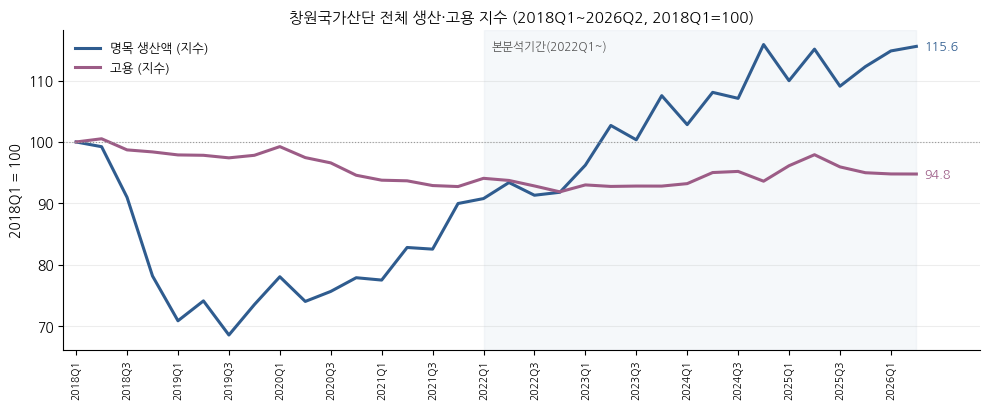

In [9]:
t = total.sort_values('quarter').reset_index(drop=True)
t['production_idx'] = t.production_total / t.production_total.iloc[0] * 100
t['employment_idx'] = t.employment_total / t.employment_total.iloc[0] * 100

fig, ax = plt.subplots(figsize=(10, 4.2))
ax.plot(t.quarter, t.production_idx, color=SERIES_COLORS['production'], lw=2.2, label='명목 생산액 (지수)')
ax.plot(t.quarter, t.employment_idx, color=SERIES_COLORS['employment'], lw=2.2, label='고용 (지수)')

main_start_i = int(t.index[t.quarter == QUARTERS[0]][0])
ax.axvspan(main_start_i, len(t) - 1, color='#4C78A8', alpha=0.05, zorder=0)
ax.axhline(100, color='#999999', lw=0.8, ls=':')
ax.text(main_start_i + 0.3, 0.97, f'본분석기간({QUARTERS[0]}~)', fontsize=8.5, color='#555555',
        va='top', ha='left', transform=ax.get_xaxis_transform())

for col, key in [('production_idx', 'production'), ('employment_idx', 'employment')]:
    ax.annotate(f'{t[col].iloc[-1]:.1f}', (len(t) - 1, t[col].iloc[-1]), xytext=(6, 0),
                textcoords='offset points', va='center', fontsize=9,
                color=SERIES_COLORS[key], fontweight='bold')

ax.set_xticks(range(0, len(t), 2))
ax.set_xticklabels(t.quarter[::2], rotation=90, fontsize=7.5)
ax.set_ylabel(f'{t.quarter.iloc[0]} = 100')
ax.set_xlim(-0.5, len(t) + 1.5)
ax.set_title(f'창원국가산단 전체 생산·고용 지수 ({t.quarter.iloc[0]}~{t.quarter.iloc[-1]}, {t.quarter.iloc[0]}=100)',
             fontsize=11)
ax.legend(loc='upper left', frameon=False, fontsize=9)
style_ax(ax)
plt.tight_layout()
save_fig(fig, 'S1_배경_총량지수')
plt.show()

print(f'{t.quarter.iloc[-1]} 기준 지수: 생산 {t.production_idx.iloc[-1]:.1f} / 고용 {t.employment_idx.iloc[-1]:.1f}')
print('주의: production_total은 명목 생산액이며 가격효과가 포함된다(Section 6 PPI 검증 참조).')

2026Q2 업종별 비중 (%, 제조업 전체 = 10개 업종 합):
           생산비중   고용비중
industry              
기계        34.03  51.19
전기전자      21.90  24.37
운송장비      29.72  14.20
철강        12.98   8.44
음식료        0.84   0.55
석유화학       0.27   0.54
목재종이       0.11   0.37
비금속        0.10   0.16
기타         0.05   0.15
섬유의복       0.00   0.03

상위 4개 업종(기계, 전기전자, 운송장비, 철강) 합계: 생산 98.6% / 고용 98.2%
5위 음식료의 고용비중 0.55% — 4위 철강(8.44%)와 15배 차이


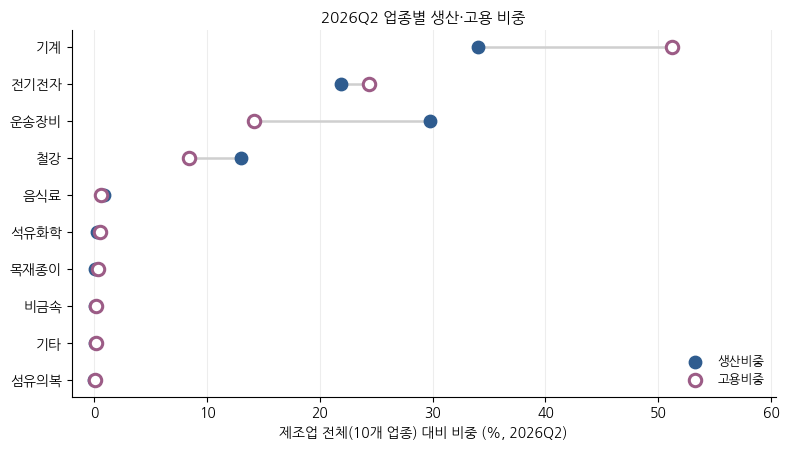

In [10]:
cur_lat = state[state.quarter == LATEST].set_index('industry')
share = pd.DataFrame({
    '생산비중': cur_lat.production / cur_lat.production.sum() * 100,
    '고용비중': cur_lat.employment / cur_lat.employment.sum() * 100,
}).reindex(IND_ORDER_EMP[::-1])

fig, ax = plt.subplots(figsize=(8, 4.6))
y = np.arange(len(share))
for yi, ind in zip(y, share.index):
    p, e = share.loc[ind, '생산비중'], share.loc[ind, '고용비중']
    ax.plot([p, e], [yi, yi], color='#CFCFCF', lw=1.8, zorder=1)
ax.scatter(share.생산비중, y, color=SERIES_COLORS['production'], s=80, zorder=2, label='생산비중')
ax.scatter(share.고용비중, y, s=80, zorder=2, label='고용비중',
           facecolor='white', edgecolor=SERIES_COLORS['employment'], linewidth=2.2)

ax.set_yticks(y)
ax.set_yticklabels(share.index, fontsize=10)
ax.set_xlabel(f'제조업 전체(10개 업종) 대비 비중 (%, {LATEST})')
ax.set_xlim(-2, max(share.max()) * 1.18)
ax.set_title(f'{LATEST} 업종별 생산·고용 비중', fontsize=11)
ax.legend(loc='lower right', frameon=False, fontsize=9)
style_ax(ax, ygrid=False, xgrid=True)
plt.tight_layout()
save_fig(fig, 'S1_배경_규모비중')
plt.show()

top4 = IND_ORDER_EMP[:4]
print(f'{LATEST} 업종별 비중 (%, 제조업 전체 = 10개 업종 합):')
print(share.sort_values('고용비중', ascending=False).round(2).to_string())
print()
print(f'상위 4개 업종({", ".join(top4)}) 합계: '
      f'생산 {share.loc[top4, "생산비중"].sum():.1f}% / 고용 {share.loc[top4, "고용비중"].sum():.1f}%')
print(f'5위 {IND_ORDER_EMP[4]}의 고용비중 {share.loc[IND_ORDER_EMP[4], "고용비중"]:.2f}% — '
      f'4위 {IND_ORDER_EMP[3]}({share.loc[IND_ORDER_EMP[3], "고용비중"]:.2f}%)와 '
      f'{share.loc[IND_ORDER_EMP[3], "고용비중"] / share.loc[IND_ORDER_EMP[4], "고용비중"]:.0f}배 차이')

In [11]:
display(Markdown(f"""### 업종 규모

최신분기 고용 상위 {len(top4)}개 업종은 **{', '.join(top4)}**이며, 고용비중 합은 **{share.loc[top4, '고용비중'].sum():.1f}%**다.
변화 방향은 모든 업종에 같은 규칙을 적용하되, 전체 인원에 미치는 규모는 Q2에서 별도로 확인한다.
"""))

### 업종 규모

최신분기 고용 상위 4개 업종은 **기계, 전기전자, 운송장비, 철강**이며, 고용비중 합은 **98.2%**다.
변화 방향은 모든 업종에 같은 규칙을 적용하되, 전체 인원에 미치는 규모는 Q2에서 별도로 확인한다.


## Section 2. Q1 상태 — 같은 고용 변화라도 산업활동 상태는 다른가?

고용 감소만으로 묶이는 업종에서도 명목 생산액은 증가하거나 감소할 수 있다.
두 지표의 전년동기 대비 방향을 결합해 S1~S4를 분류한다. 어느 한 지표가 0%이면 N, 계산할 수 없으면 INVALID다.
생산 증가가 실제 물량 증가라는 뜻은 아니다. PPI 민감도는 Section 6에서 별도로 확인한다.

2026Q2 업종별 국면 (고용비중 내림차순):
          생산YoY%  고용YoY%  국면    고용(명)  고용비중%
industry                                    
기계        -19.55   -6.34  S4  58784.0  51.19
전기전자        2.70   -0.41  S2  27979.0  24.37
운송장비       19.64   -0.78  S2  16308.0  14.20
철강         32.65   -1.14  S2   9689.0   8.44
음식료         0.87   -3.79  S2    635.0   0.55
석유화학       -6.73    9.56  S3    619.0   0.54
목재종이      -12.90  -10.08  S4    428.0   0.37
비금속        45.67   -1.08  S2    183.0   0.16
기타          3.03   17.12  S1    171.0   0.15
섬유의복      -12.32    0.00   N     34.0   0.03

2026Q2 고용 감소 업종 7개 중 생산이 증가한 업종은 5개(전기전자, 운송장비, 철강, 음식료, 비금속)이며, 이들의 고용비중 합계는 47.7%였다.


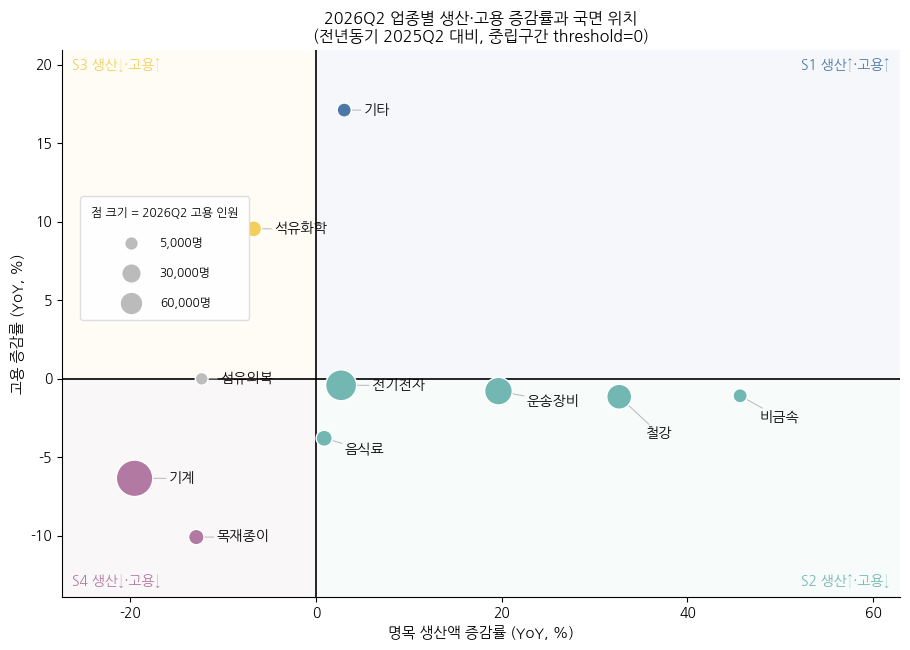

In [12]:
# ---- Q1-A. 최신분기 업종별 국면 위치 -----------------------------------------
q = state[(state.quarter == LATEST) & state.valid_state].set_index('industry')
q = q.reindex([i for i in IND_ORDER_EMP if i in q.index])

fig, ax = plt.subplots(figsize=(9.2, 6.6))

xpad = (q.production_yoy.max() - q.production_yoy.min()) * 0.12
ypad = (q.employment_yoy.max() - q.employment_yoy.min()) * 0.14
xlim = (q.production_yoy.min() - xpad, q.production_yoy.max() + xpad * 2.2)
ylim = (q.employment_yoy.min() - ypad, q.employment_yoy.max() + ypad)
ax.set_xlim(xlim); ax.set_ylim(ylim)

# 사분면 배경 — 아주 옅게. 코너 라벨이 국면 의미를 직접 말한다.
for (sx, sy), s in [((1, 1), 'S1'), ((1, -1), 'S2'), ((-1, 1), 'S3'), ((-1, -1), 'S4')]:
    x0 = 0 if sx > 0 else xlim[0]
    y0 = 0 if sy > 0 else ylim[0]
    ax.add_patch(Rectangle((x0, y0), (xlim[1] if sx > 0 else 0) - x0,
                           (ylim[1] if sy > 0 else 0) - y0,
                           color=STATE_COLORS[s], alpha=0.055, lw=0, zorder=0))
    ax.text(xlim[1] - (xlim[1] - xlim[0]) * 0.012 if sx > 0 else xlim[0] + (xlim[1] - xlim[0]) * 0.012,
            ylim[1] - (ylim[1] - ylim[0]) * 0.015 if sy > 0 else ylim[0] + (ylim[1] - ylim[0]) * 0.015,
            STATE_LABELS[s], ha='right' if sx > 0 else 'left', va='top' if sy > 0 else 'bottom',
            fontsize=10, color=STATE_COLORS[s], fontweight='bold', zorder=1)

ax.axhline(0, color='black', lw=1.2, zorder=2)
ax.axvline(0, color='black', lw=1.2, zorder=2)

emp_max = q.employment.max()
sizes = 70 + 620 * np.sqrt(q.employment / emp_max)
ax.scatter(q.production_yoy, q.employment_yoy, s=sizes,
           color=[STATE_COLORS[s] for s in q.state],
           edgecolor='white', linewidth=1.0, zorder=4)

radii = (np.sqrt(sizes / np.pi) + 6) * 1.4   # points -> 화면 px 환산
# 라벨은 업종명만 — 고용 인원은 점 크기와 범례가 이미 전달한다(라벨을 길게 하면 서로 겹친다).
place_labels(ax, q.production_yoy.values, q.employment_yoy.values, list(q.index),
             offsets=radii, fontsize=10.2, min_gap_px=15, split_at=0)

# 점 크기 범례 — 텍스트 설명 대신 실제 원으로 보여준다.
leg_vals = [5_000, 30_000, 60_000]
handles = [Line2D([], [], marker='o', ls='', markerfacecolor='#BBBBBB', markeredgecolor='white',
                  markersize=np.sqrt(70 + 620 * np.sqrt(v / emp_max)) * 0.62,
                  label=f'{v:,}명') for v in leg_vals]
# 사분면 코너 라벨과 겹치지 않도록 좌측 여백(관측치가 없는 영역)에 둔다.
ax.legend(handles=handles, loc='center left', bbox_to_anchor=(0.015, 0.62),
          frameon=True, framealpha=0.95, edgecolor='#DDDDDD',
          fontsize=8.6, title=f'점 크기 = {LATEST} 고용 인원', title_fontsize=8.6,
          labelspacing=1.5, borderpad=0.9, handletextpad=1.4)

ax.set_xlabel('명목 생산액 증감률 (YoY, %)', fontsize=10.5)
ax.set_ylabel('고용 증감률 (YoY, %)', fontsize=10.5)
ax.set_title(f'{LATEST} 업종별 생산·고용 증감률과 국면 위치\n'
             f'(전년동기 {BASE_Q} 대비, 중립구간 threshold={THRESHOLD})', fontsize=11.5)
style_ax(ax, ygrid=False)
plt.tight_layout()
save_fig(fig, 'Q1A_최신분기_사분면')
plt.show()

d = state[state.quarter == LATEST].set_index('industry').reindex(IND_ORDER_EMP)
tbl = pd.DataFrame({
    '생산YoY%': d.production_yoy, '고용YoY%': d.employment_yoy,
    '국면': d.state, '고용(명)': d.employment,
    '고용비중%': d.employment / d.employment.sum() * 100,
})
print(f'{LATEST} 업종별 국면 (고용비중 내림차순):')
print(tbl.round(2).to_string())
print()
dn = d[(d.employment_yoy < 0) & d.valid_state]
up = dn[dn.production_yoy > 0]
results_summary['q1_latest'] = {'quarter': LATEST, 'n_down': len(dn), 'n_nominal_up': len(up),
    'nominal_up_industries': list(up.index), 'employment_denominator': float(d.employment.sum()),
    'nominal_employment_numerator': float(up.employment.sum()),
    'nominal_employment_share_pct': float(up.employment.sum()/d.employment.sum()*100)}

print(f'{LATEST} 고용 감소 업종 {len(dn)}개 중 생산이 증가한 업종은 {len(up)}개'
      f'({", ".join(up.index)})이며, 이들의 고용비중 합계는 '
      f'{results_summary["q1_latest"]["nominal_employment_share_pct"]:.1f}%였다.')


In [13]:
r = results_summary['q1_latest']
display(Markdown(f"""### 最新분기의 상태

고용이 감소한 **{r['n_down']}개** 업종 중 명목 생산액이 증가한 업종은 **{r['n_nominal_up']}개**다.
해당 업종은 {', '.join(r['nominal_up_industries'])}이며, 고용비중 합은 **{r['nominal_employment_share_pct']:.1f}%**다.

이 비율의 분모는 고용 감소 업종만의 인원이 아니라 **제조업 전체 고용 {r['employment_denominator']:,.0f}명**이다.
같은 고용 감소에도 생산액 방향이 다르다는 관측이며, 원인이나 지원 필요성을 입증하지 않는다.
""".replace('最新', '최신')))

### 최신분기의 상태

고용이 감소한 **7개** 업종 중 명목 생산액이 증가한 업종은 **5개**다.
해당 업종은 전기전자, 운송장비, 철강, 음식료, 비금속이며, 고용비중 합은 **47.7%**다.

이 비율의 분모는 고용 감소 업종만의 인원이 아니라 **제조업 전체 고용 114,830명**이다.
같은 고용 감소에도 생산액 방향이 다르다는 관측이며, 원인이나 지원 필요성을 입증하지 않는다.


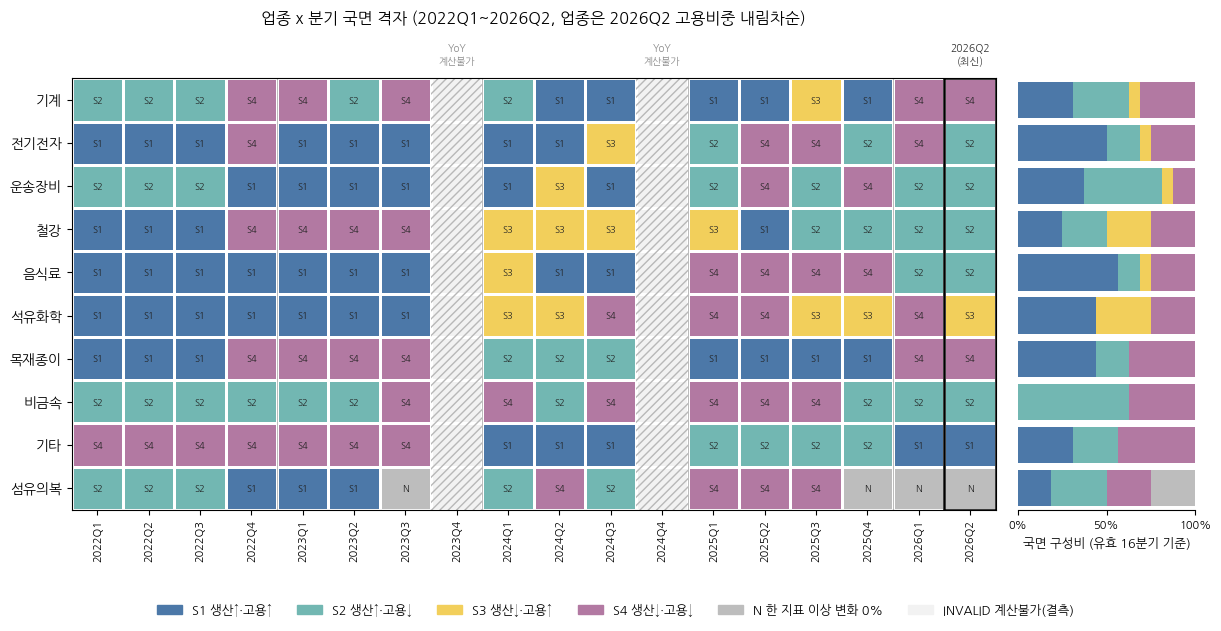

In [14]:
# ---- Q1-B. 관측기간 업종x분기 국면 분포 --------------------------------------
pivot = state.pivot(index='industry', columns='quarter', values='state').reindex(
    index=IND_ORDER_EMP, columns=QUARTERS)
code_map = {s: i for i, s in enumerate(STATES6)}
code_arr = pivot.apply(lambda col: col.map(code_map)).astype(float).values
n_ind, n_q = code_arr.shape

fig = plt.figure(figsize=(14.5, 5.6))
gs = fig.add_gridspec(1, 2, width_ratios=[5.2, 1], wspace=0.04)
ax = fig.add_subplot(gs[0])
axr = fig.add_subplot(gs[1], sharey=ax)

cmap = ListedColormap([STATE_COLORS[s] for s in STATES6])
norm = BoundaryNorm(np.arange(-0.5, len(STATES6) + 0.5, 1), cmap.N)
ax.pcolormesh(code_arr, cmap=cmap, norm=norm, edgecolors='white', linewidth=0.8)

ax.set_xticks(np.arange(n_q) + 0.5)
ax.set_xticklabels(QUARTERS, rotation=90, fontsize=8)
ax.set_yticks(np.arange(n_ind) + 0.5)
ax.set_yticklabels(IND_ORDER_EMP, fontsize=10)
ax.set_ylim(0, n_ind)
ax.invert_yaxis()

for ri in range(n_ind):
    for qi in range(n_q):
        label = pivot.iloc[ri, qi]
        if label != 'INVALID':
            ax.text(qi+.5, ri+.5, label, ha='center', va='center', fontsize=6.7, color='#222222')

for q_inv in INVALID_QUARTERS:
    qi = QUARTERS.index(q_inv)
    for ri in range(n_ind):
        ax.add_patch(Rectangle((qi, ri), 1, 1, fill=False, hatch='////',
                               edgecolor='#B8B8B8', linewidth=0))
    ax.text(qi + 0.5, -0.28, 'YoY\n계산불가', ha='center', va='bottom', fontsize=7, color='#888888')

for i, qq in enumerate(QUARTERS):
    if qq.endswith('Q1'):
        ax.axvline(i, color='#AAAAAA', lw=0.7, alpha=0.8)
ax.add_patch(Rectangle((n_q - 1, 0), 1, n_ind, fill=False, edgecolor='black', linewidth=1.8))
ax.text(n_q - 0.5, -0.28, f'{LATEST}\n(최신)', ha='center', va='bottom', fontsize=7.5,
        color='#333333', fontweight='bold')

# 우측: 업종별 국면 구성비. INVALID는 두 분기 모두 전 업종 공통이라 정보가 없어 제외하고,
# 유효 분기(16분기) 기준으로 정규화한다. y좌표는 히트맵 셀 중심(+0.5)에 맞춘다.
valid = state[state.state != 'INVALID']
comp = (pd.crosstab(valid.industry, valid.state, normalize='index')
        .reindex(index=IND_ORDER_EMP).reindex(columns=STATES5, fill_value=0))
yb = np.arange(n_ind) + 0.5
left = np.zeros(n_ind)
for col in STATES5:
    axr.barh(yb, comp[col].values, left=left, color=STATE_COLORS[col], height=0.84)
    left += comp[col].values
axr.set_xlim(0, 1)
axr.set_xticks([0, 0.5, 1]); axr.set_xticklabels(['0%', '50%', '100%'], fontsize=8)
axr.set_xlabel(f'국면 구성비 (유효 {len(QUARTERS) - len(INVALID_QUARTERS)}분기 기준)', fontsize=9)
plt.setp(axr.get_yticklabels(), visible=False)
axr.tick_params(axis='y', length=0)
axr.spines['top'].set_visible(False); axr.spines['right'].set_visible(False)
axr.spines['left'].set_visible(False)

handles = [Rectangle((0, 0), 1, 1, color=STATE_COLORS[k]) for k in STATES6]
fig.legend(handles, [STATE_LABELS[k] for k in STATES6], loc='lower center', ncol=6,
           bbox_to_anchor=(0.5, -0.10), frameon=False, fontsize=9)
ax.set_title(f'업종 x 분기 국면 격자 ({QUARTERS[0]}~{LATEST}, 업종은 {LATEST} 고용비중 내림차순)',
             fontsize=11.5, pad=40)
plt.tight_layout()
save_fig(fig, 'Q1B_국면격자')
plt.show()

In [15]:
print('업종별 국면 분포 (분기 수):')
print(pd.crosstab(state.industry, state.state).reindex(IND_ORDER_EMP)
      .reindex(columns=STATES6, fill_value=0).to_string())
print()
print('분기별 국면 분포 (업종 수):')
print(pd.crosstab(state.quarter, state.state).reindex(QUARTERS)
      .reindex(columns=STATES6, fill_value=0).to_string())
print()
emp_down = state[(state.employment_yoy < 0) & state.valid_state]
simple_pct = (emp_down.production_yoy > 0).mean()
weighted_pct = ((emp_down.production_yoy > 0) * emp_down.employment).sum() / emp_down.employment.sum()
t4 = emp_down[emp_down.industry.isin(IND_ORDER_EMP[:4])]
print(f'전체 관측기간 고용 감소 관측치(n={len(emp_down)}) 중 생산이 오히려 증가한 비율:')
print(f'  단순 비율          : {simple_pct:.1%}')
print(f'  고용 인원 가중      : {weighted_pct:.1%}')
print(f'  상위 4개 업종 한정  : {(t4.production_yoy > 0).mean():.1%} (n={len(t4)})')
results_summary['q1_history'] = {'n_down': len(emp_down), 'n_up_down': int((emp_down.production_yoy>0).sum()),
    'simple_pct': float(simple_pct*100), 'weighted_pct': float(weighted_pct*100)}


업종별 국면 분포 (분기 수):
state     S1  S2  S3  S4  N  INVALID
industry                            
기계         5   5   1   5  0        2
전기전자       8   3   1   4  0        2
운송장비       6   7   1   2  0        2
철강         4   4   4   4  0        2
음식료        9   2   1   4  0        2
석유화학       7   0   5   4  0        2
목재종이       7   3   0   6  0        2
비금속        0  10   0   6  0        2
기타         5   4   0   7  0        2
섬유의복       3   5   0   4  4        2

분기별 국면 분포 (업종 수):
state    S1  S2  S3  S4  N  INVALID
quarter                            
2022Q1    5   4   0   1  0        0
2022Q2    5   4   0   1  0        0
2022Q3    5   4   0   1  0        0
2022Q4    4   1   0   5  0        0
2023Q1    5   1   0   4  0        0
2023Q2    5   2   0   3  0        0
2023Q3    4   0   0   5  1        0
2023Q4    0   0   0   0  0       10
2024Q1    3   3   3   1  0        0
2024Q2    4   2   3   1  0        0
2024Q3    4   2   2   2  0        0
2024Q4    0   0   0   0  0       10
2025Q1    2   3

참고: ±0.5/1/2% 민감도는 본분석(threshold=0)을 대체하지 않으며, 국면 경계 부근 관측치가 얼마나
민감한지만 확인한다.

In [16]:
# 중립구간만 변경한 보조집계. 본분석 국면은 유지한다.
sensitivity_rows = []
for threshold in [0.5, 1.0, 2.0]:
    values = [classify(r.production_yoy, r.employment_yoy, threshold) for r in state.itertuples()]
    counts = pd.Series(values).value_counts().reindex(STATES6, fill_value=0)
    sensitivity_rows.append({'threshold': threshold, **counts.to_dict()})
sens_summary = pd.DataFrame(sensitivity_rows).set_index('threshold')
display(sens_summary)
print('같은 패널에서 중립구간만 변경한 보조 집계다. 기존 민감도 CSV와의 대조 검증은 하지 않았다.')

같은 패널에서 중립구간만 변경한 보조 집계다. 기존 민감도 CSV와의 대조 검증은 하지 않았다.


,S1,S2,S3,S4,N,INVALID
threshold,,,,,,
0.5,51,41,11,46,11,20
1.0,50,33,11,43,23,20
2.0,41,29,7,36,47,20


In [17]:
r = results_summary['q1_history']
display(Markdown(f"""### 관측기간 전체

고용 감소 관측 **{r['n_down']}건** 중 명목 생산 증가가 **{r['n_up_down']}건({r['simple_pct']:.1f}%)**이다.
각 업종×분기의 고용 인원으로 가중하면 **{r['weighted_pct']:.1f}%**다.
두 수치는 각각 관측 건수와 고용 규모를 기준으로 보므로 의미가 다르다. 반복 관측을 서로 독립인 표본으로 간주하지 않는다.
"""))

### 관측기간 전체

고용 감소 관측 **89건** 중 명목 생산 증가가 **43건(48.3%)**이다.
각 업종×분기의 고용 인원으로 가중하면 **53.0%**다.
두 수치는 각각 관측 건수와 고용 규모를 기준으로 보므로 의미가 다르다. 반복 관측을 서로 독립인 표본으로 간주하지 않는다.


## Section 3. Q2 규모 — 제조업 전체 고용 증감에서 어떤 업종의 변화가 큰가?

국면은 방향을 보여주지만 인원 변화의 크기는 알려주지 않는다. 업종별 고용 증감 인원과 고용비중을 함께 확인한다.
고용 규모와 변화 규모를 기준으로 상세 경로를 표시할 업종을 정한다. 모든 업종은 전체 표와 지속·전환 집계에 포함한다.

기여율은 업종별 증감을 제조업 전체 순증감으로 나눈 값이다.
순증감이 작아 비율이 과도해지는 경우에는 증감 인원을 중심으로 제시하며, 표시 기준은 Section 0의 설정을 따른다.

2026Q2 제조업 전체(10개 업종) 고용 114,830명, 전년동기 대비 -4,332명 (-3.64%)
업종별 증감 절대합 4,490명 / 순변화/총변화 비율 0.965 -> 기여율 사용 가능

               고용    고용_전년    증감인원   증감률%  고용비중%  국면   기여율%
industry                                                   
기계        58784.0  62763.0 -3979.0  -6.34  51.19  S4  91.85
운송장비      16308.0  16437.0  -129.0  -0.78  14.20  S2   2.98
전기전자      27979.0  28095.0  -116.0  -0.41  24.37  S2   2.68
철강         9689.0   9801.0  -112.0  -1.14   8.44  S2   2.59
목재종이        428.0    476.0   -48.0 -10.08   0.37  S4   1.11
음식료         635.0    660.0   -25.0  -3.79   0.55  S2   0.58
비금속         183.0    185.0    -2.0  -1.08   0.16  S2   0.05
섬유의복         34.0     34.0     0.0   0.00   0.03   N  -0.00
기타          171.0    146.0    25.0  17.12   0.15  S1  -0.58
석유화학        619.0    565.0    54.0   9.56   0.54  S3  -1.25


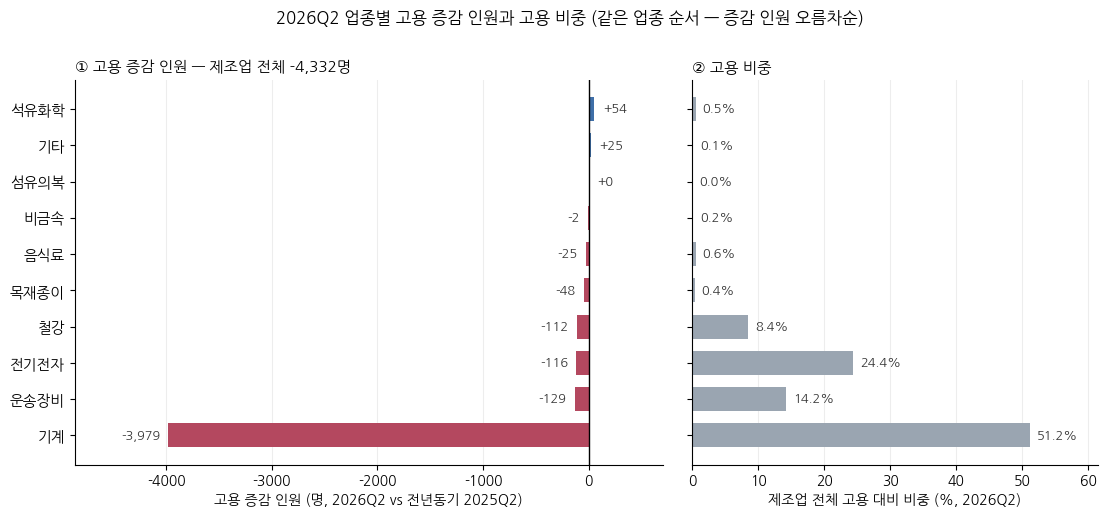

In [18]:
# ---- Q2-A. 최신분기 고용 증감 인원 | 고용 비중 --------------------------------
d = state[state.quarter == LATEST].set_index('industry')
q2 = pd.DataFrame({
    '고용': d.employment,
    '고용_전년': d.employment_lag4_lvl,
    '증감인원': d.emp_delta,
    '증감률%': d.employment_yoy,
    '고용비중%': d.employment / d.employment.sum() * 100,
    '국면': d.state,
}).sort_values('증감인원')
net = q2.증감인원.sum()
ratio = mfg.loc[LATEST, 'net_gross_ratio']
usable = bool(mfg.loc[LATEST, 'contrib_usable'])
if usable:
    q2['기여율%'] = q2.증감인원 / net * 100

fig, axes = plt.subplots(1, 2, figsize=(13.2, 5.0), sharey=True,
                         gridspec_kw={'width_ratios': [1.45, 1], 'wspace': 0.06})
y = np.arange(len(q2))

ax = axes[0]
ax.barh(y, q2.증감인원, height=0.66,
        color=[DELTA_COLORS['down'] if v < 0 else (DELTA_COLORS['up'] if v > 0 else DELTA_COLORS['neutral'])
               for v in q2.증감인원])
ax.axvline(0, color='black', lw=1.0)
bar_labels(ax, y, q2.증감인원.values, fmt=lambda v: f'{v:+,.0f}', fontsize=9.2)
ax.set_yticks(y); ax.set_yticklabels(q2.index, fontsize=10.5)
ax.set_xlabel(f'고용 증감 인원 (명, {LATEST} vs 전년동기 {BASE_Q})', fontsize=10.2)
_span = q2.증감인원.max() - q2.증감인원.min()
ax.set_xlim(q2.증감인원.min() - _span * 0.22, max(q2.증감인원.max(), 0) + _span * 0.16)
ax.set_title(f'① 고용 증감 인원 — 제조업 전체 {net:+,.0f}명', fontsize=11, loc='left')
style_ax(ax, ygrid=False, xgrid=True)

ax = axes[1]
ax.barh(y, q2['고용비중%'], height=0.66, color='#9AA5B1')
bar_labels(ax, y, q2['고용비중%'].values, fmt=lambda v: f'{v:.1f}%', fontsize=9.2)
ax.set_xlabel(f'제조업 전체 고용 대비 비중 (%, {LATEST})', fontsize=10.2)
ax.set_xlim(0, max(q2['고용비중%'].max()*1.2, 1))
ax.set_title('② 고용 비중', fontsize=11, loc='left')
style_ax(ax, ygrid=False, xgrid=True)

fig.suptitle(f'{LATEST} 업종별 고용 증감 인원과 고용 비중 (같은 업종 순서 — 증감 인원 오름차순)',
             fontsize=12, y=1.02)
plt.tight_layout()
save_fig(fig, 'Q2A_고용증감_비중')
plt.show()

print(f'{LATEST} 제조업 전체(10개 업종) 고용 {q2.고용.sum():,.0f}명, '
      f'전년동기 대비 {net:+,.0f}명 ({net / q2.고용_전년.sum() * 100:+.2f}%)')
print(f'업종별 증감 절대합 {q2.증감인원.abs().sum():,.0f}명 / 순변화/총변화 비율 {ratio:.3f}'
      f' -> 기여율 사용 {"가능" if usable else "불가"}')
print()
print(q2.round(2).to_string())

막대는 주요 업종과 나머지 업종의 순증감 합이다. 나머지 그룹 내부의 상쇄는 그림에 드러나지 않는다. 총변화는 아래 표의 업종별 증감 절대합을 따른다.

분기별 순증감 / 총변화 / 순변화/총변화 비율:
            순증감     총변화  순변화/총변화 비율
quarter                            
2022Q1    280.0  5652.0       0.050
2022Q2    -70.0  5838.0       0.012
2022Q3   -266.0  4878.0       0.055
2022Q4  -3381.0  4597.0       0.735
2023Q1  -3571.0  9621.0       0.371
2023Q2  -3488.0  8118.0       0.430
2023Q3  -2191.0  8711.0       0.252
2023Q4   1178.0  9516.0       0.124
2024Q1    269.0  1073.0       0.251
2024Q2   2939.0  3029.0       0.970
2024Q3   2944.0  3066.0       0.960
2024Q4   1063.0  2207.0       0.482
2025Q1   2918.0  5858.0       0.498
2025Q2   2863.0  7161.0       0.400
2025Q3    202.0  4286.0       0.047
2025Q4    873.0  6481.0       0.135
2026Q1  -1965.0  2009.0       0.978
2026Q2  -4332.0  4490.0       0.965


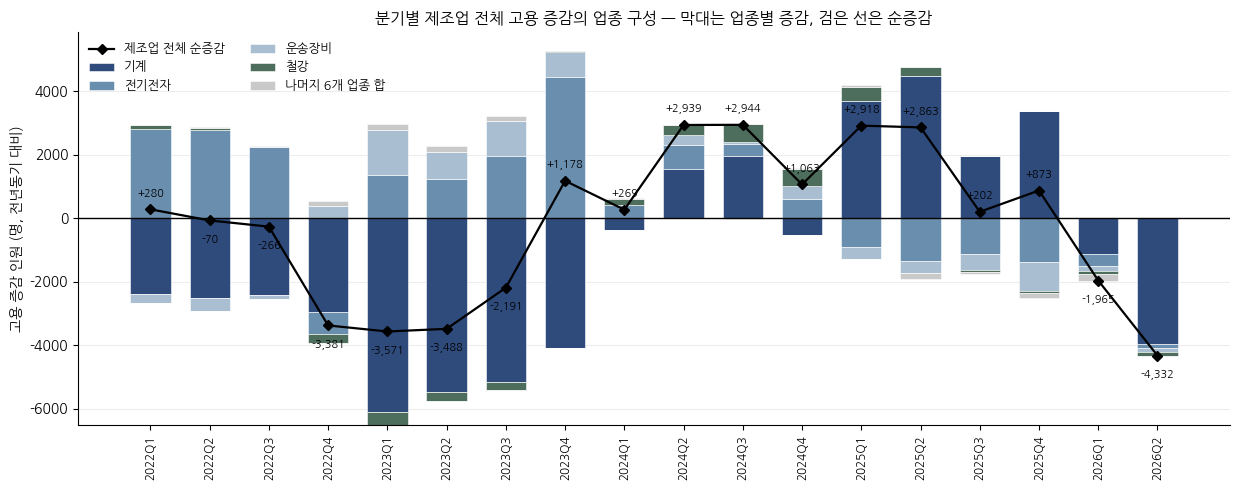

In [19]:
# ---- Q2-B. 분기별 제조업 전체 고용 변화의 업종 구성 ---------------------------
MAIN_CAND = IND_ORDER_EMP[:4]
REST = [i for i in IND_ORDER_EMP if i not in MAIN_CAND]

dd = state.dropna(subset=['emp_delta'])
qs = [q for q in QUARTERS if q in set(dd.quarter)]
piv = dd.pivot_table(index='quarter', columns='industry', values='emp_delta').reindex(qs)
plot_df = piv[MAIN_CAND].copy()
plot_df[f'나머지 {len(REST)}개 업종 합'] = piv[REST].sum(axis=1)
cols = list(plot_df.columns)
colors = MAIN_COLORS + [REST_COLOR]

fig, ax = plt.subplots(figsize=(12.5, 5.0))
x = np.arange(len(qs))
pos = np.zeros(len(qs)); neg = np.zeros(len(qs))
for col, c in zip(cols, colors):
    v = plot_df[col].fillna(0).values
    vp = np.where(v > 0, v, 0); vn = np.where(v < 0, v, 0)
    ax.bar(x, vp, bottom=pos, color=c, width=0.68, label=col, edgecolor='white', linewidth=0.4)
    ax.bar(x, vn, bottom=neg, color=c, width=0.68, edgecolor='white', linewidth=0.4)
    pos += vp; neg += vn

netv = plot_df.sum(axis=1).values
ax.plot(x, netv, color='black', lw=1.6, marker='D', ms=5, zorder=5, label='제조업 전체 순증감')
for xi, v in zip(x, netv):
    ax.annotate(f'{v:+,.0f}', (xi, v), xytext=(0, 9 if v >= 0 else -16), textcoords='offset points',
                ha='center', fontsize=7.8, color='black', fontweight='bold')

ax.axhline(0, color='black', lw=1.0)
ax.set_xticks(x); ax.set_xticklabels(qs, rotation=90, fontsize=8.5)
ax.set_ylabel('고용 증감 인원 (명, 전년동기 대비)', fontsize=10.2)
ax.set_title('분기별 제조업 전체 고용 증감의 업종 구성 — 막대는 업종별 증감, 검은 선은 순증감',
             fontsize=11.5)
ax.legend(loc='upper left', frameon=False, fontsize=9, ncol=2)
style_ax(ax)
plt.tight_layout()
save_fig(fig, 'Q2B_분기별_고용변화구성')
plt.show()

print('막대는 주요 업종과 나머지 업종의 순증감 합이다. 나머지 그룹 내부의 상쇄는 그림에 드러나지 않는다. 총변화는 아래 표의 업종별 증감 절대합을 따른다.')
print()
print('분기별 순증감 / 총변화 / 순변화/총변화 비율:')
print(mfg.loc[qs, ['mfg_emp_delta', 'mfg_emp_gross', 'net_gross_ratio']]
      .rename(columns={'mfg_emp_delta': '순증감', 'mfg_emp_gross': '총변화', 'net_gross_ratio': '순변화/총변화 비율'})
      .round(3).to_string())

In [20]:
RECENT4 = QUARTERS[-4:]
rec_state = state[state.quarter.isin(RECENT4)]
rec = rec_state.groupby('industry').emp_delta.agg(
    최근4분기_YoY증감합='sum', 최근4분기_YoY증감절대합=lambda s:s.abs().sum())
# Four quarterly stock changes telescope to latest minus t-4, not the sum of YoY differences.
rec['최근4분기_기간순증감'] = q2.증감인원
summary = pd.DataFrame({'고용비중%': q2['고용비중%'], f'{LATEST}_증감인원':q2.증감인원,
    f'{LATEST}_증감률%':q2['증감률%'], f'{LATEST}_국면':q2.국면}).join(rec).reindex(IND_ORDER_EMP)
SHARE_CUT = 5.0
ABS_CUT = 300
c1 = summary['고용비중%'] >= SHARE_CUT
c2 = summary['최근4분기_YoY증감절대합'] >= ABS_CUT
MAIN_IND = [i for i in IND_ORDER_EMP if c1[i] and c2[i]]
summary['상세표시대상'] = c1 & c2
display(summary.round(2))
results_summary['q2'] = {'quarter': LATEST, 'employment':float(q2.고용.sum()), 'net_delta':float(net),
    'net_yoy_pct':float(net/q2.고용_전년.sum()*100), 'ratio':float(ratio), 'contrib_usable':usable,
    'largest_decrease_industries':q2.index[q2.증감인원.eq(q2.증감인원.min()) & q2.증감인원.lt(0)].tolist(),
    'min_delta':float(q2.증감인원.min()), 'main_industries':MAIN_IND,
    'main_share_pct':float(summary.loc[MAIN_IND,'고용비중%'].sum()),
    'selection_share_cut':SHARE_CUT,'selection_abs_cut':ABS_CUT}
print(f'상세표시 기준: 고용비중 {SHARE_CUT:g}% 이상, 최근 {len(RECENT4)}분기 YoY 증감 절대합 {ABS_CUT:,}명 이상.')
print('기존 표시 기준을 유지한 것이며, 정책 우선순위 또는 통계적으로 검증된 경계가 아니다. 모든 업종은 전체 표에 남긴다.')
print('YoY 증감합은 동일 인원이 여러 분기에 반복 반영될 수 있어 신규·소멸 일자리 수나 기간 순증감으로 해석하지 않는다.')
summary.to_csv(DIR_TAB/'Q2_규모요약.csv', encoding='utf-8-sig')

상세표시 기준: 고용비중 5% 이상, 최근 4분기 YoY 증감 절대합 300명 이상.
기존 표시 기준을 유지한 것이며, 정책 우선순위 또는 통계적으로 검증된 경계가 아니다. 모든 업종은 전체 표에 남긴다.
YoY 증감합은 동일 인원이 여러 분기에 반복 반영될 수 있어 신규·소멸 일자리 수나 기간 순증감으로 해석하지 않는다.


,고용비중%,2026Q2_증감인원,2026Q2_증감률%,2026Q2_국면,최근4분기_YoY증감합,최근4분기_YoY증감절대합,최근4분기_기간순증감,상세표시대상
industry,,,,,,,,
기계,51.19,-3979.0,-6.34,S4,238.0,10478.0,-3979.0,True
전기전자,24.37,-116.0,-0.41,S2,-3009.0,3009.0,-116.0,True
운송장비,14.20,-129.0,-0.78,S2,-1717.0,1717.0,-129.0,True
철강,8.44,-112.0,-1.14,S2,-309.0,309.0,-112.0,True
음식료,0.55,-25.0,-3.79,S2,-772.0,772.0,-25.0,False
석유화학,0.54,54.0,9.56,S3,95.0,105.0,54.0,False
목재종이,0.37,-48.0,-10.08,S4,418.0,616.0,-48.0,False
비금속,0.16,-2.0,-1.08,S2,-128.0,128.0,-2.0,False
기타,0.15,25.0,17.12,S1,-34.0,128.0,25.0,False


In [21]:
r = results_summary['q2']
change_word = '감소' if r['net_delta'] < 0 else ('증가' if r['net_delta'] > 0 else '변화 없음')
smallest_text = ', '.join(r['largest_decrease_industries']) or '해당 없음'
display(Markdown(f"""### 고용 변화의 규모

{LATEST} 제조업 고용은 **{r['employment']:,.0f}명**이며, 전년동기 대비 **{r['net_delta']:+,.0f}명({r['net_yoy_pct']:+.1f}%)**다.
감소 인원이 가장 큰 업종은 **{smallest_text}**다. 상세 경로를 표시할 업종은 **{', '.join(MAIN_IND) or '없음'}**이다.

최근 분기들의 YoY 증감합과 기간 순증감은 구분한다. 기업별 채용·퇴사·재분류는 업종 합계만으로 나눌 수 없다.
"""))

### 고용 변화의 규모

2026Q2 제조업 고용은 **114,830명**이며, 전년동기 대비 **-4,332명(-3.6%)**다.
감소 인원이 가장 큰 업종은 **기계**다. 상세 경로를 표시할 업종은 **기계, 전기전자, 운송장비, 철강**이다.

최근 분기들의 YoY 증감합과 기간 순증감은 구분한다. 기업별 채용·퇴사·재분류는 업종 합계만으로 나눌 수 없다.


## Section 4. Q3 시간 — 국면은 얼마나 이어지고 어떤 경로로 바뀌는가?

같은 국면이 연속된 기간과 인접한 두 분기의 상태를 확인한다.
지속기간은 기존 전처리 정의대로 S1~S4만 집계하고, 인접 전환표에는 N도 포함한다.
결측 구간을 연결하지 않는다. YoY는 비교 기간이 겹치므로 연속된 상태를 독립적인 반복 증거로 취급하지 않는다.

모든 패널의 y축 범위는 같다. 아래 리본은 명목 기준 국면이며 PPI 조정 국면이 아니다.
기계     생산 YoY   -19.5 ~   21.9% | 고용 YoY   -9.7 ~   7.7%
전기전자   생산 YoY    -7.8 ~   25.7% | 고용 YoY   -4.7 ~  18.4%
운송장비   생산 YoY   -13.8 ~   44.5% | 고용 YoY   -5.3 ~   9.1%
철강     생산 YoY   -15.2 ~   53.8% | 고용 YoY   -4.3 ~   6.0%


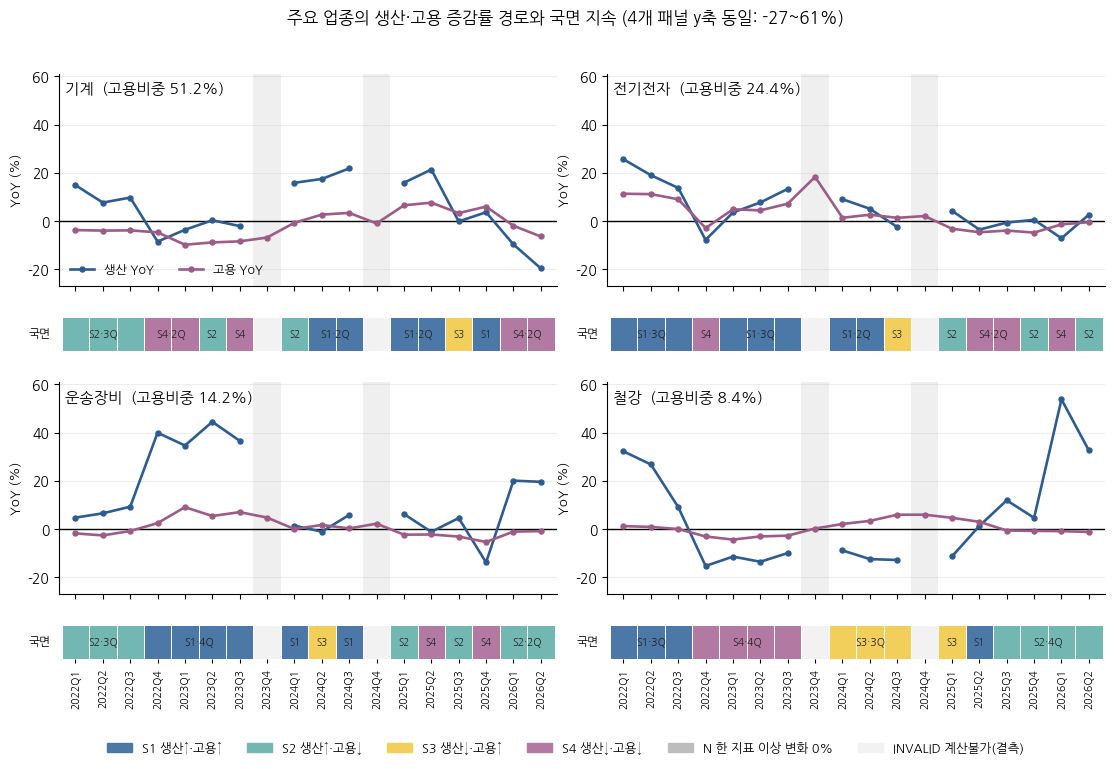

In [22]:
# ---- Q3-A. 주요 업종의 생산·고용 YoY 경로 + 국면 리본(연속기간) ----------------
sub = state[state.industry.isin(MAIN_IND)]
ymin = min(sub.production_yoy.min(), sub.employment_yoy.min())
ymax = max(sub.production_yoy.max(), sub.employment_yoy.max())
pad = (ymax - ymin) * 0.10
qi_all = sorted(state.quarter_index.unique())
qi2x = {qi: i for i, qi in enumerate(qi_all)}

panel_rows = max(1, int(np.ceil(len(MAIN_IND)/2)))
fig = plt.figure(figsize=(13.5, 3.8*panel_rows))
gs = fig.add_gridspec(panel_rows*2, 2, height_ratios=[1, 0.16]*panel_rows, hspace=0.25, wspace=0.10)
cmap = ListedColormap([STATE_COLORS[s] for s in STATES6])
norm = BoundaryNorm(np.arange(-0.5, len(STATES6) + 0.5, 1), cmap.N)
code_map = {s: i for i, s in enumerate(STATES6)}

for k, ind in enumerate(MAIN_IND):
    r, c = 2*(k//2), k%2
    axl = fig.add_subplot(gs[r, c])
    axb = fig.add_subplot(gs[r + 1, c])

    g = state[state.industry == ind].sort_values('quarter_index')
    xs = [qi2x[v] for v in g.quarter_index]

    axl.axhline(0, color='black', lw=1.0)
    for q_inv in INVALID_QUARTERS:                       # 결측 분기를 옅은 세로띠로 표시
        axl.axvspan(qi2x[g.loc[g.quarter == q_inv, 'quarter_index'].iloc[0]] - 0.5,
                    qi2x[g.loc[g.quarter == q_inv, 'quarter_index'].iloc[0]] + 0.5,
                    color='#EFEFEF', lw=0, zorder=0)
    axl.plot(xs, g.production_yoy, color=SERIES_COLORS['production'], lw=1.9, marker='o', ms=3.6,
             label='생산 YoY')
    axl.plot(xs, g.employment_yoy, color=SERIES_COLORS['employment'], lw=1.9, marker='o', ms=3.6,
             label='고용 YoY')
    axl.set_ylim(ymin - pad, ymax + pad)
    axl.set_xlim(-0.6, len(qi_all) - 0.4)
    axl.set_xticks(range(len(qi_all)))
    axl.set_xticklabels([])
    emp_sh = g.loc[g.quarter == LATEST, 'employment'].iloc[0] / \
        state.loc[state.quarter == LATEST, 'employment'].sum() * 100
    axl.text(0.012, 0.965, f'{ind}  (고용비중 {emp_sh:.1f}%)', transform=axl.transAxes,
             va='top', fontsize=11, fontweight='bold')
    axl.set_ylabel('YoY (%)', fontsize=9.5)
    style_ax(axl)
    if k == 0:
        axl.legend(loc='lower left', frameon=False, fontsize=8.8, ncol=2)

    arr = np.array([[code_map[s] for s in g.state]], dtype=float)
    axb.pcolormesh(np.arange(len(qi_all) + 1) - 0.5, np.array([0.0, 1.0]), arr,
                   cmap=cmap, norm=norm, edgecolors='white', linewidth=0.7)
    axb.set_xlim(axl.get_xlim()); axb.set_yticks([])
    axb.set_xticks(np.arange(len(qi_all)))
    # 분기 라벨은 아래쪽 두 패널에만 — 위 패널 리본의 라벨은 아래 패널 제목과 겹친다
    axb.set_xticklabels(g.quarter if k//2 == panel_rows-1 else [''] * len(qi_all), rotation=90, fontsize=7.6)
    axb.tick_params(axis='x', length=3 if k//2 == panel_rows-1 else 0)
    for sp in axb.spines.values():
        sp.set_visible(False)
    # 연속기간(2분기 이상)를 리본 위에 숫자로 표기 — Q1B 격자가 보여주지 않는 정보
    states_list = g.state.tolist()
    i = 0
    while i < len(states_list):
        s = states_list[i]
        j = i
        while j + 1 < len(states_list) and states_list[j + 1] == s:
            j += 1
        run_len = j - i + 1
        if s in STATES4 and run_len >= 2:
            axb.text((i + j) / 2, 0.5, f'{s}·{run_len}Q', ha='center', va='center',
                     fontsize=7.6, color='#222222', fontweight='bold')
        elif s in STATES4:
            axb.text((i + j) / 2, 0.5, s, ha='center', va='center',
                     fontsize=7.0, color='#222222')
        i = j + 1
    axb.set_ylabel('국면', fontsize=8.5, rotation=0, ha='right', va='center', labelpad=6)

handles = [Rectangle((0, 0), 1, 1, color=STATE_COLORS[k]) for k in STATES6]
fig.legend(handles, [STATE_LABELS[k] for k in STATES6], loc='lower center', ncol=6,
           bbox_to_anchor=(0.5, -0.03), frameon=False, fontsize=9)
fig.suptitle(f'주요 업종의 생산·고용 증감률 경로와 국면 지속 ({len(MAIN_IND)}개 패널 y축 동일: '
             f'{ymin - pad:.0f}~{ymax + pad:.0f}%)', fontsize=12, y=0.965)
save_fig(fig, 'Q3A_주요업종_경로')
plt.show()

print('모든 패널의 y축 범위는 같다. 아래 리본은 명목 기준 국면이며 PPI 조정 국면이 아니다.')
for ind in MAIN_IND:
    g = state[state.industry == ind].sort_values('quarter_index')
    print(f'{ind:6s} 생산 YoY {g.production_yoy.min():7.1f} ~ {g.production_yoy.max():6.1f}% | '
          f'고용 YoY {g.employment_yoy.min():6.1f} ~ {g.employment_yoy.max():5.1f}%')

◁ 는 run이 관측 블록의 시작과 함께 시작해 실제 지속기간이 더 길 수 있음을 뜻한다(좌측 절단).
좌측 절단 업종: 없음


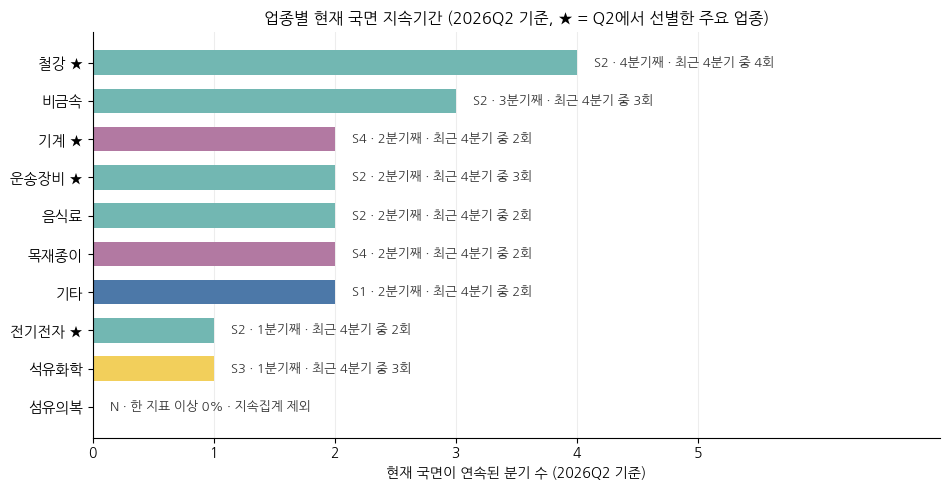

In [23]:
# ---- Q3-B. 현재 국면 지속기간 -------------------------------------------------
cur = state[state.quarter == LATEST].set_index('industry').reindex(IND_ORDER_EMP)
_sort_key = pd.DataFrame({'_sort': cur.run_length.fillna(-1),
                          '_share': cur.employment / cur.employment.sum()})
cur = cur.loc[_sort_key.sort_values(['_sort', '_share'], ascending=[False, False]).index]

fig, ax = plt.subplots(figsize=(9.6, 5.0))
y = np.arange(len(cur))
bar_len = cur.run_length.fillna(0)
ax.barh(y, bar_len, color=[STATE_COLORS.get(s, '#BDBDBD') for s in cur.state], height=0.64)
ax.set_yticks(y)
ax.set_yticklabels([f'{i} ★' if i in MAIN_IND else i for i in cur.index], fontsize=10.5)
ax.invert_yaxis()
ax.set_xlabel(f'현재 국면이 연속된 분기 수 ({LATEST} 기준)', fontsize=10.2)
ax.set_xlim(0, bar_len.max() + 3.0)
ax.set_xticks(range(0, int(bar_len.max()) + 2))

for yi, (ind, row) in zip(y, cur.iterrows()):
    if row.state == 'N':
        label = 'N · 한 지표 이상 0% · 지속집계 제외'
    elif row.state == 'INVALID':
        label = '계산 불가 · 지속집계 제외'
    else:
        recent = int(row[f'recent4_{row.state}_count'])
        label = f'{row.state} · {int(row.run_length)}분기째 · 최근 4분기 중 {recent}회'
    ax.text(bar_len[ind] + 0.14, yi, label, va='center', fontsize=9.3, color='#333333')
    if pd.notna(row.run_left_censored) and bool(row.run_left_censored):
        ax.text(-0.22, yi, '◁', va='center', ha='right', fontsize=11, color='#555555')

ax.set_title(f'업종별 현재 국면 지속기간 ({LATEST} 기준, ★ = Q2에서 선별한 주요 업종)', fontsize=11.5)
style_ax(ax, ygrid=False, xgrid=True)
plt.tight_layout()
save_fig(fig, 'Q3B_현재국면_지속')
plt.show()

print('◁ 는 run이 관측 블록의 시작과 함께 시작해 실제 지속기간이 더 길 수 있음을 뜻한다(좌측 절단).')
print(f'좌측 절단 업종: {cur.index[cur.run_left_censored.fillna(False).astype(bool)].tolist() or "없음"}')

In [24]:
# ---- run 분포 · 최장 지속기간 · 최근 전환경로 ---------------------------------
runs = state.dropna(subset=['run_id']).drop_duplicates(['industry', 'run_id'])
share2plus = (runs.run_total_length >= 2).mean() * 100

print('연속기간 분포 (연속구간 단위, 업종x분기 아님):')
print(runs.run_total_length.astype(int).value_counts().sort_index()
      .rename_axis('지속분기').to_frame('run 수').T.to_string())
print(f'전체 {len(runs)}개 run 중 2분기 이상 {int((runs.run_total_length >= 2).sum())}개 '
      f'({share2plus:.1f}%), 평균 {runs.run_total_length.mean():.2f}분기, '
      f'최장 {runs.run_total_length.max():.0f}분기')
print()
print('최장 지속 사례 (관측 블록 경계에 걸려 양끝 절단 가능):')
print(runs.sort_values('run_total_length', ascending=False).head(6)
      [['industry', 'state', 'state_start_quarter', 'run_total_length',
        'run_left_censored', 'run_right_censored']]
      .rename(columns={'run_total_length': '지속분기', 'run_left_censored': '좌절단',
                       'run_right_censored': '우절단'}).to_string(index=False))
print()
print('업종별 최장 지속 run:')
longest = (runs.sort_values('run_total_length', ascending=False)
           .drop_duplicates('industry').set_index('industry')
           [['state', 'state_start_quarter', 'run_total_length']]
           .reindex(IND_ORDER_EMP)
           .rename(columns={'state': '국면', 'state_start_quarter': '시작분기',
                            'run_total_length': '지속분기'}))
print(longest.to_string())
print()
print(f'업종별 최근 6분기 국면 경로 ({QUARTERS[-6]}~{LATEST}):')
for ind in IND_ORDER_EMP:
    star = ' ★' if ind in MAIN_IND else '  '
    print(f'  {ind:6s}{star} {state_path(ind, 6)}')
print()
print('S2(생산확대·고용감소) / S4(동반감소) run 중 2분기 이상 지속된 사례:')
s2s4 = runs[runs.state.isin(['S2', 'S4']) & (runs.run_total_length >= 2)]
print(s2s4[['industry', 'state', 'state_start_quarter', 'run_total_length']]
      .rename(columns={'run_total_length': '지속분기'})
      .sort_values('지속분기', ascending=False).to_string(index=False))

연속기간 분포 (연속구간 단위, 업종x분기 아님):
지속분기    1   2   3  4  6  7
run 수  31  14  14  7  1  3
전체 70개 run 중 2분기 이상 39개 (55.7%), 평균 2.23분기, 최장 7분기

최장 지속 사례 (관측 블록 경계에 걸려 양끝 절단 가능):
industry state state_start_quarter  지속분기  좌절단   우절단
    석유화학    S1              2022Q1   7.0 True  True
      기타    S4              2022Q1   7.0 True  True
     음식료    S1              2022Q1   7.0 True  True
     비금속    S2              2022Q1   6.0 True False
      기타    S2              2025Q1   4.0 True False
    목재종이    S1              2025Q1   4.0 True False

업종별 최장 지속 run:
          국면    시작분기  지속분기
industry                  
기계        S2  2022Q1   3.0
전기전자      S1  2022Q1   3.0
운송장비      S1  2022Q4   4.0
철강        S2  2025Q3   4.0
음식료       S1  2022Q1   7.0
석유화학      S1  2022Q1   7.0
목재종이      S1  2025Q1   4.0
비금속       S2  2022Q1   6.0
기타        S4  2022Q1   7.0
섬유의복      S1  2022Q4   3.0

업종별 최근 6분기 국면 경로 (2025Q1~2026Q2):
  기계     ★ S1 → S1 → S3 → S1 → S4 → S4
  전기전자   ★ S2 → S4 → S4 → S2 → S4 → S2
  운송장비   ★ S2 

관측된 전환 130건 중 같은 국면으로 이어진 전환 88건(67.7%)

건수 기준 주요 전환경로 (상위 8개):
  S1 -> S1 : 35건 (78% of S1 행)  [유지]
  S4 -> S4 : 24건 (65% of S4 행)  [유지]
  S2 -> S2 : 23건 (64% of S2 행)  [유지]
  S4 -> S2 :  9건 (24% of S4 행)  [전환]
  S2 -> S4 :  9건 (25% of S2 행)  [전환]
  S1 -> S4 :  5건 (11% of S1 행)  [전환]
  S3 -> S3 :  4건 (40% of S3 행)  [유지]
  S2 -> S1 :  4건 (11% of S2 행)  [전환]


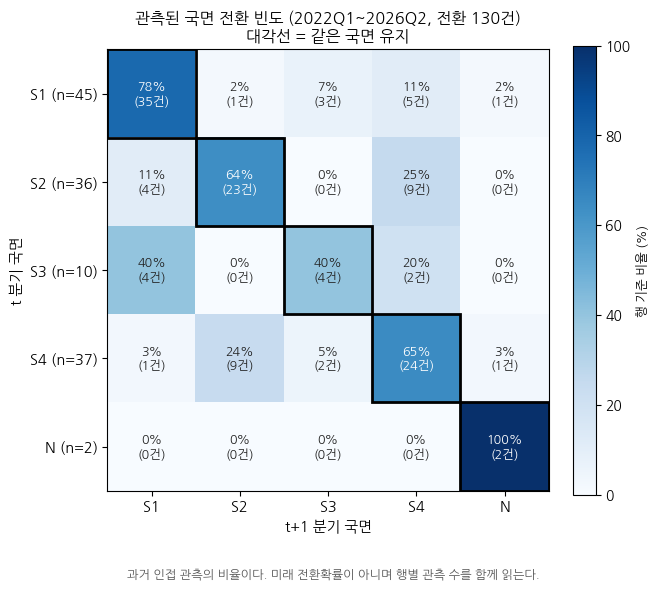

In [25]:
# ---- Q3-C. 관측된 국면 전환 빈도 ---------------------------------------------
trans = state[state.valid_transition5 == True]
mat = pd.crosstab(trans.state, trans.next_state).reindex(index=STATES5, columns=STATES5, fill_value=0)
row_n = mat.sum(axis=1)
mat_pct = mat.div(row_n, axis=0).fillna(0) * 100
diag = sum(mat.loc[s, s] for s in STATES5)

fig, ax = plt.subplots(figsize=(6.6, 5.9))
im = ax.imshow(mat_pct.values, cmap='Blues', vmin=0, vmax=100)
ax.set_xticks(range(5)); ax.set_xticklabels(STATES5, fontsize=10.5)
ax.set_yticks(range(5))
ax.set_yticklabels([f'{s} (n={row_n[s]})' for s in STATES5], fontsize=10.5)
ax.set_xlabel('t+1 분기 국면', fontsize=10.5)
ax.set_ylabel('t 분기 국면', fontsize=10.5)
for i in range(5):
    for j in range(5):
        pct, cnt = mat_pct.values[i, j], mat.values[i, j]
        ax.text(j, i, f'{pct:.0f}%\n({cnt}건)', ha='center', va='center', fontsize=9,
                color='white' if pct > 55 else '#222222')
    ax.add_patch(Rectangle((i - 0.5, i - 0.5), 1, 1, fill=False, edgecolor='black', linewidth=2))
cbar = plt.colorbar(im, ax=ax, fraction=0.046)
cbar.set_label('행 기준 비율 (%)', fontsize=9)
ax.set_title(f'관측된 국면 전환 빈도 ({QUARTERS[0]}~{LATEST}, 전환 {len(trans)}건)\n'
             '대각선 = 같은 국면 유지', fontsize=11.5)
fig.text(0.5, -0.02,
         '과거 인접 관측의 비율이다. 미래 전환확률이 아니며 행별 관측 수를 함께 읽는다.',
         ha='center', fontsize=8.8, color='#555555')
plt.tight_layout()
save_fig(fig, 'Q3C_전환행렬')
plt.show()

print(f'관측된 전환 {len(trans)}건 중 같은 국면으로 이어진 전환 {diag}건({diag / len(trans):.1%})')
print()
print('건수 기준 주요 전환경로 (상위 8개):')
paths = (trans.groupby(['state', 'next_state']).size().sort_values(ascending=False).head(8))
for (a, b), n in paths.items():
    tag = '유지' if a == b else '전환'
    print(f'  {a} -> {b} : {n:2d}건 ({n / row_n[a]:.0%} of {a} 행)  [{tag}]')
results_summary['q3'] = {'n_runs':len(runs), 'n_runs_2plus':int((runs.run_total_length>=2).sum()),
    'share_2plus_pct':float(share2plus), 'mean_run':float(runs.run_total_length.mean()),
    'max_run':int(runs.run_total_length.max()), 'n_adjacent':len(trans), 'n_same':int(diag),
    'same_pct':float(diag/len(trans)*100), 'current':[
        {'industry':i, 'state':r.state, 'length':None if pd.isna(r.run_length) else int(r.run_length)}
        for i,r in cur.iterrows()]}


In [26]:
r=results_summary['q3']
display(Markdown(f"""### 관측된 지속과 전환

S1~S4의 연속구간 **{r['n_runs']}개** 중 **{r['n_runs_2plus']}개({r['share_2plus_pct']:.1f}%)**가 두 분기 이상 이어졌다.
최장 관측 길이는 **{r['max_run']}분기**다. N을 포함한 인접 관측 **{r['n_adjacent']}건** 중 **{r['n_same']}건({r['same_pct']:.1f}%)**이 같은 상태였다.

이는 관측기간 내 지속·전환의 요약이다. 결측 구간과 진행 중인 최신 국면 때문에 실제 전체 지속기간은 확정할 수 없다.
빈도만으로 향후 국면이나 구조적 원인을 예측하지 않는다.
"""))

### 관측된 지속과 전환

S1~S4의 연속구간 **70개** 중 **39개(55.7%)**가 두 분기 이상 이어졌다.
최장 관측 길이는 **7분기**다. N을 포함한 인접 관측 **130건** 중 **88건(67.7%)**이 같은 상태였다.

이는 관측기간 내 지속·전환의 요약이다. 결측 구간과 진행 중인 최신 국면 때문에 실제 전체 지속기간은 확정할 수 없다.
빈도만으로 향후 국면이나 구조적 원인을 예측하지 않는다.


## Section 5. 보조분석 — 주요 업종의 가동률·업체수

Q1~Q3를 보완하기 위해 가동률과 업체수의 움직임을 함께 확인한다.
각 지표가 있는 기간만 사용하며, 가동률 수준과 가동업체/입주업체 비율을 구분한다.
고용을 업체수와 업체당 평균 인원으로 나눈 산술 분해는 기업별 고용 원인 분석이 아니다.

업종 고용/가동업체수는 산술적인 평균이다. 동일 사업장 표본을 추적한 값이 아니므로 폐업·감원·채용의 원인별 인원으로 해석하지 않는다.
가동률과 가동업체/입주업체 비율은 서로 다른 지표다.


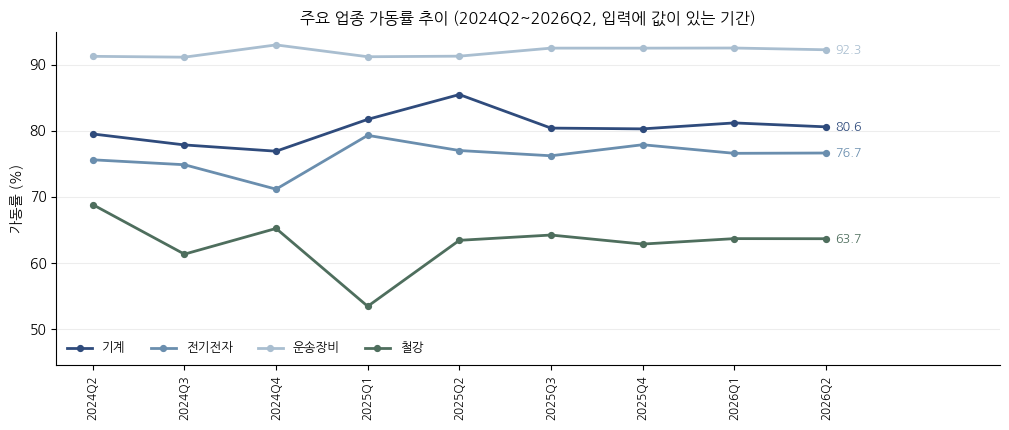

,고용증감,가동업체_전년,가동업체_당분기,업체당_전년,업체당_당분기,업체수증감,업체수변화항,평균인원변화항,교차항
industry,,,,,,,,,
기계,-3979.0,1453.0,1458.0,43.20,40.32,5.0,215.98,-4180.59,-14.39
전기전자,-116.0,571.0,590.0,49.20,47.42,19.0,934.86,-1017.02,-33.84
운송장비,-129.0,244.0,245.0,67.36,66.56,1.0,67.36,-195.56,-0.80
철강,-112.0,75.0,74.0,130.68,130.93,-1.0,-130.68,18.93,-0.25


,국면,가동률%,가동률YoY(%p),입주업체,입주YoY%,가동업체,가동YoY%,가동업체비율
industry,,,,,,,,
기계,S4,80.61,-4.89,1556.0,1.37,1458.0,0.34,0.94
전기전자,S2,76.65,-0.38,651.0,1.88,590.0,3.33,0.91
운송장비,S2,92.28,0.97,254.0,0.79,245.0,0.41,0.96
철강,S2,63.68,0.24,80.0,1.27,74.0,-1.33,0.92
음식료,S2,92.30,-1.43,7.0,0.00,4.0,0.00,0.57
석유화학,S3,76.31,-3.32,49.0,8.89,45.0,9.76,0.92
목재종이,S4,74.71,6.01,48.0,-4.00,44.0,-2.22,0.92
비금속,S2,57.30,14.11,4.0,-20.00,4.0,-20.00,1.00
기타,S1,69.14,1.61,35.0,-5.41,25.0,-7.41,0.71


In [27]:
op = state[state.op_rate_official.notna()]
op_qs = sorted(op.quarter.unique())

fig, ax = plt.subplots(figsize=(10.2, 4.4))
x = np.arange(len(op_qs))
for ind, c in zip(MAIN_IND, MAIN_COLORS):
    g = op[op.industry == ind].set_index('quarter').reindex(op_qs)
    ax.plot(x, g.op_rate_official, color=c, lw=2.0, marker='o', ms=4.2, label=ind)
    ax.annotate(f'{g.op_rate_official.iloc[-1]:.1f}', (x[-1], g.op_rate_official.iloc[-1]),
                xytext=(7, 0), textcoords='offset points', va='center', fontsize=9,
                color=c, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(op_qs, rotation=90, fontsize=8.5)
ax.set_xlim(-0.4, len(op_qs) + 0.9)
ax.set_ylabel('가동률 (%)', fontsize=10.2)
_lo, _hi = ax.get_ylim()
ax.set_ylim(_lo - (_hi - _lo) * 0.16, _hi)     # 좌하단 범례가 선을 가리지 않도록 여백
ax.set_title(f'주요 업종 가동률 추이 ({op_qs[0]}~{op_qs[-1]}, 입력에 값이 있는 기간)', fontsize=11.5)
ax.legend(loc='lower left', frameon=False, fontsize=9, ncol=4)
style_ax(ax)
plt.tight_layout()
save_fig(fig, 'S5_보조_가동률추이')
plt.show()

# E = F × (E/F)의 산술 분해. 실제 기업별 고용 흐름 분해가 아니다.
_m = state[state.quarter == LATEST].set_index('industry').reindex(MAIN_IND)
_b = pd.DataFrame({'employment':_m.employment_lag4, 'firms_op':_m.firms_op_lag4})
_epf_b = _b.employment / _b.firms_op.replace(0,np.nan)
_epf_m = _m.employment / _m.firms_op.replace(0,np.nan)
margin = pd.DataFrame({'고용증감':_m.emp_delta, '가동업체_전년':_b.firms_op,
    '가동업체_당분기':_m.firms_op, '업체당_전년':_epf_b, '업체당_당분기':_epf_m})
margin['업체수증감'] = _m.firms_op - _b.firms_op
margin['업체수변화항'] = margin.업체수증감*_epf_b
margin['평균인원변화항'] = _b.firms_op*(_epf_m-_epf_b)
margin['교차항'] = margin.업체수증감*(_epf_m-_epf_b)
assert np.allclose(margin[['업체수변화항','평균인원변화항','교차항']].sum(axis=1),margin.고용증감)
display(margin.round(2))
print('업종 고용/가동업체수는 산술적인 평균이다. 동일 사업장 표본을 추적한 값이 아니므로 폐업·감원·채용의 원인별 인원으로 해석하지 않는다.')
aux = state[state.quarter == LATEST].set_index('industry').reindex(IND_ORDER_EMP)
aux_tbl = pd.DataFrame({'국면':aux.state, '가동률%':aux.op_rate_official,
    '가동률YoY(%p)':aux.op_rate_official_yoy_pp, '입주업체':aux.firms_in,
    '입주YoY%':aux.firms_in_yoy, '가동업체':aux.firms_op, '가동YoY%':aux.firms_op_yoy,
    '가동업체비율':aux.active_firm_ratio})
display(aux_tbl.round(2))
print('가동률과 가동업체/입주업체 비율은 서로 다른 지표다.')


In [28]:
_op_valid = state[state.op_rate_official_yoy_pp.notna()]
display(Markdown(f"""### 보조지표의 범위

가동률 전년동기 차이를 계산할 수 있는 범위는 **{_op_valid.quarter.min()}~{_op_valid.quarter.max()}**, **{len(_op_valid)}건**이다.
고용과 업체수가 같은 방향으로 변하는지 확인하되, 업체수 변화항을 실제 사업장 진입·퇴출 인원으로 읽지 않는다.
"""))

### 보조지표의 범위

가동률 전년동기 차이를 계산할 수 있는 범위는 **2025Q2~2026Q2**, **50건**이다.
고용과 업체수가 같은 방향으로 변하는지 확인하되, 업체수 변화항을 실제 사업장 진입·퇴출 인원으로 읽지 않는다.


## Section 6. 보조분석 — PPI · EIS

PPI는 선택한 가격지수에 따라 생산 방향의 해석이 달라지는지 확인한다.
EIS는 범위가 다른 두 고용 통계의 흐름을 함께 읽기 위한 배경자료이며, KICOX의 정확성을 입증하는 정답 자료가 아니다.

### PPI — 선택한 가격지수에 따른 생산 방향 비교

**결정: 후보 매핑은 조건부 민감도 분석에 사용하고, 명목 생산 기준 본분석은 유지한다.**

월별 PPI를 계열 코드별로 선택하고, 세 달이 모두 있는 분기만 산술평균한다.
분기 평균의 전년동기 비율을 구한 후 다음과 같이 조정한다.

$$g_{adj}=100\left[\frac{1+g_{nom}/100}{1+g_{ppi}/100}-1\right]$$

이는 분기 명목 생산액을 분기 평균 PPI로 나눈 값의 YoY와 같다.
월별 생산액 가중치가 없으므로 월별로 조정한 생산액을 합한 결과와 같다고 가정하지 않는다.

- 단일 후보는 해당 지수를 대입한 시나리오다. 1:1 품목 대응이 검증되었다는 뜻이 아니다.
- 복수 후보는 각 지수로 계산한 결과의 최솟값·최댓값을 제시한다. 확률적 신뢰구간이나 실제 조정값의 보장된 범위가 아니다.
- 모든 후보에서 명목과 같은 부호 / 모든 후보에서 반대 부호 / 후보별 부호 차이 / 0% 경계를 구분한다.
- 기타는 대응 범위를 정할 근거가 없어 제외한다. 철강1차제품은 철강 관련 후보로 사용하되 전체 업종 구성의 대표성을 확정하지 않는다.

`confirmed`는 승인 대기 의미가 불명확해 제거한다. `mapping_use='sensitivity_only'`,
`main_analysis_eligible=False`로 분석 역할을 명시한다. `aux_usable` 대신 `sensitivity_eligible`을 사용한다.
각 후보의 자료가 완전할 때만 비교에 포함한다.

한국은행은 PPI를 국내에서 생산되어 국내시장에 출하되는 상품·서비스의 가격지수로 설명한다.
전국 지수의 품목 구성, 내수·수출 범위, 산단의 생산 가중치가 일치한다고 확인되지 않았으므로
이 조정값을 산단의 실제 물량·생산성·정확한 실질생산으로 해석하지 않는다.

참고: [한국은행 물가지수 설명](https://www.bok.or.kr/portal/bbs/B0000216/view.do?menuNo=200134&nttId=165633&pageIndex=)

In [29]:
# PPI 원자료 → 코드별 월 패널 → 완전한 분기 평균 → 달력 기준 YoY
ppi_path = ROOT/'data/raw/ppi/ppi_raw.csv'
record_input(ppi_path, '공유된 PPI 원자료')
raw = pd.read_csv(ppi_path, dtype=str)
raw.columns = raw.columns.str.lstrip('\ufeff')
raw['C1'] = raw.C1.str.strip()
raw['DT'] = pd.to_numeric(raw.DT, errors='coerce')
raw['month'] = pd.to_datetime(raw.PRD_DE, format='%Y%m').dt.to_period('M')
series_keys = ['ORG_ID','TBL_ID','ITM_ID','C1','PRD_SE']
# 코드/명칭은 결과 하드코딩이 아니라 분석에 사용한 입력 매핑이다.
mapping_rows = [
    ('기계','311','기계및장비','분류가 가까운 단일 후보'),
    ('운송장비','312','운송장비','전국 운송장비 전체 후보; 산단 품목 비중 미확인'),
    ('비금속','306','비금속광물제품','분류가 가까운 단일 후보'),
    ('음식료','301','음식료품','분류가 가까운 단일 후보'),
    ('목재종이','303','목재및종이제품','분류가 가까운 단일 후보'),
    ('섬유의복','3021','섬유및의복','가죽을 포함하는 상위 항목 대신 하위 후보'),
    ('철강','3071','철강1차제품','비철금속을 포함하는 상위 지수 대신 철강 후보; 가공품 구성 미확인'),
    ('석유화학','304','석탄및석유제품','품목별 가중치 없이 두 후보를 각각 적용'),
    ('석유화학','305','화학제품','품목별 가중치 없이 두 후보를 각각 적용'),
    ('전기전자','309','컴퓨터전자및광학기기','품목별 가중치 없이 두 후보를 각각 적용'),
    ('전기전자','310','전기장비','품목별 가중치 없이 두 후보를 각각 적용'),
]
ppi_map = pd.DataFrame(mapping_rows, columns=['industry','code_suffix','ppi_item','mapping_reason'])
ppi_map['C1'] = '13102134604ACC_CD.'+ppi_map.code_suffix+'AA'
ppi_map['mapping_use'] = 'sensitivity_only'
ppi_map['main_analysis_eligible'] = False
ppi_map['sensitivity_eligible'] = True
ppi_map['series_level_digits'] = ppi_map.code_suffix.str.len()
ppi_map = pd.concat([ppi_map, pd.DataFrame([{'industry':'기타','mapping_reason':'대응 범위 근거 부족',
    'mapping_use':'excluded','main_analysis_eligible':False,'sensitivity_eligible':False}])], ignore_index=True)
selected_map = ppi_map[ppi_map.sensitivity_eligible]
selected = raw[(raw.ORG_ID.eq('301')) & raw.TBL_ID.eq('DT_404Y014') &
    raw.ITM_ID.eq('13103134604999') & raw.PRD_SE.eq('M') & raw.C1.isin(selected_map.C1)].copy()
assert set(selected.C1) == set(selected_map.C1), 'PPI 코드 누락'
assert not selected.duplicated(series_keys+['month']).any(), '동일 PPI 코드/월 중복: 평균처리 금지'
assert selected.UNIT_NM.str.replace('＝','=').eq('2020=100').all(), '사용 계열 기준연도 혼재'
assert selected.DT.gt(0).all(), 'PPI 결측 또는 0 이하'
name_by_code = selected.groupby('C1').C1_NM.agg(lambda x: set(x))
assert all(name_by_code[r.C1] == {r.ppi_item} for r in selected_map.itertuples()), 'PPI 코드-이름 불일치'
calendar = pd.period_range(raw.month.min(), raw.month.max(), freq='M')
monthly = selected.pivot(index='month', columns='C1', values='DT').reindex(calendar)
monthly_missing = monthly.isna().sum()
# 월이 하나라도 없으면 그 분기는 계산하지 않는다. 빈 월을 보간하지 않는다.
monthly['quarter'] = monthly.index.asfreq('Q')
quarterly = monthly.groupby('quarter').mean()
counts = monthly.groupby('quarter').count()
quarterly = quarterly.where(counts.eq(3))
quarterly = quarterly.reindex(pd.period_range(quarterly.index.min(), quarterly.index.max(), freq='Q'))
# 수준값으로 계산한 조정 생산 YoY와 변화율 공식이 일치하는지도 확인한다.
ppi_level_long = quarterly.rename_axis('quarter').reset_index().melt(id_vars='quarter',var_name='C1',value_name='ppi_level')
ppi_lag_long = quarterly.shift(4).rename_axis('quarter').reset_index().melt(id_vars='quarter',var_name='C1',value_name='ppi_level_lag4')
ppi_level_long = ppi_level_long.merge(ppi_lag_long,on=['quarter','C1'],validate='one_to_one')
ppi_level_long['quarter']=ppi_level_long.quarter.astype(str)
ppi_yoy = (quarterly / quarterly.shift(4) - 1)*100
ppi_yoy.index.name = 'quarter'
ppi_long = ppi_yoy.reset_index().melt(id_vars='quarter',var_name='C1',value_name='ppi_yoy')
ppi_long['quarter'] = ppi_long.quarter.astype(str)
ppi_long = ppi_long.merge(selected_map[['industry','C1','ppi_item']],on='C1',validate='many_to_one')
assert not ppi_long.duplicated(['quarter','industry','C1']).any()
assert ppi_long.loc[ppi_long.quarter < str(quarterly.index[0]+4),'ppi_yoy'].isna().all(), '초기 YoY 오류'
base = state[state.production_yoy.notna() & state.employment_yoy.notna()][
    ['quarter','industry','production_yoy','employment_yoy','state','employment']]
mm = base.merge(ppi_long,on=['quarter','industry'],how='inner',validate='one_to_many')
expected_candidates = selected_map.groupby('industry').size()
complete = mm.groupby(['quarter','industry']).ppi_yoy.count().rename('n_valid').reset_index()
complete['n_expected'] = complete.industry.map(expected_candidates)
complete = complete[complete.n_valid.eq(complete.n_expected)]
mm = mm.merge(complete[['quarter','industry']],on=['quarter','industry'],validate='many_to_one')
mm['adjusted_yoy'] = ((1+mm.production_yoy/100)/(1+mm.ppi_yoy/100)-1)*100
# 0% 입력의 수치오차만 처리한다. 분석 중립구간은 변경하지 않는다.
mm.loc[mm.adjusted_yoy.abs()<1e-10,'adjusted_yoy'] = 0
level_check = mm.merge(ppi_level_long,on=['quarter','C1'],validate='many_to_one').merge(
    state[['quarter','industry','production','production_lag4']],on=['quarter','industry'],validate='many_to_one')
level_yoy = ((level_check.production/(level_check.ppi_level/100))/
             (level_check.production_lag4/(level_check.ppi_level_lag4/100))-1)*100
assert np.allclose(level_yoy,level_check.adjusted_yoy), 'PPI 수준값 공식과 YoY 조정 공식 불일치'

sig = mm.groupby(['quarter','industry','production_yoy','employment_yoy','state'],as_index=False).agg(
    adjusted_lo=('adjusted_yoy','min'), adjusted_hi=('adjusted_yoy','max'),
    ppi_lo=('ppi_yoy','min'), ppi_hi=('ppi_yoy','max'), n_candidates=('C1','nunique'),
    ppi_items=('ppi_item',lambda s:'; '.join(sorted(s.unique()))))
nom = np.sign(sig.production_yoy)
sig['all_same'] = np.sign(sig.adjusted_lo).eq(nom) & np.sign(sig.adjusted_hi).eq(nom)
sig['all_opposite'] = (nom.ne(0) & np.sign(sig.adjusted_lo).eq(-nom) & np.sign(sig.adjusted_hi).eq(-nom))
sig['status'] = np.select([sig.all_same, sig.all_opposite,
    sig.adjusted_lo.lt(0)&sig.adjusted_hi.gt(0)],
    ['모든 후보에서 유지','모든 후보에서 반전','후보별 방향 다름'],default='0% 경계 변화')
sig['adjusted_state'] = [classify(r.adjusted_lo,r.employment_yoy)
    if classify(r.adjusted_lo,r.employment_yoy)==classify(r.adjusted_hi,r.employment_yoy) else '후보별 상이'
    for r in sig.itertuples()]
sig['different'] = ~sig.all_same
ppi_year = sig.assign(year=sig.quarter.str[:4]).groupby('year').agg(
    관측수=('status','size'), 전체후보반전=('all_opposite','sum'),
    후보의존=('status',lambda s:s.eq('후보별 방향 다름').sum()),
    차이관측=('different','sum'))
ppi_year['차이비율%'] = ppi_year.차이관측/ppi_year.관측수*100
latest_all = state[state.quarter.eq(LATEST)].set_index('industry')
latest_sig = sig[sig.quarter.eq(LATEST)].set_index('industry')
# 명목 증가 업종에 한정해서 조정 결과를 찾지 않는다: 음→양의 변화도 포착한다.
comparable_down = latest_sig[latest_sig.employment_yoy.lt(0)]
nom_up = comparable_down[comparable_down.production_yoy.gt(0)]
adj_up = comparable_down[comparable_down.adjusted_lo.gt(0)]
adj_possible_up = comparable_down[comparable_down.adjusted_hi.gt(0)]
emp_den = results_summary['q1_latest']['employment_denominator']
nom_num = float(latest_all.loc[nom_up.index,'employment'].sum())
adj_num = float(latest_all.loc[adj_up.index,'employment'].sum())
possible_num = float(latest_all.loc[adj_possible_up.index,'employment'].sum())
target = base[base.industry.isin(selected_map.industry)]
raw_series = raw[series_keys+['C1_NM']].drop_duplicates()
raw_month_counts=raw.groupby('C1').month.nunique()
raw_incomplete=raw_month_counts[raw_month_counts < len(calendar)]
raw_other_units=raw[raw.UNIT_NM.str.replace('＝','=').ne('2020=100')][['C1_NM','UNIT_NM']].drop_duplicates()
selected_audit=selected_map[['industry','C1','ppi_item','series_level_digits']].copy()
selected_audit['n_months']=selected_audit.C1.map(selected.groupby('C1').month.nunique())
selected_audit['missing_months']=selected_audit.C1.map(monthly_missing)
selected_audit['unit']=selected_audit.C1.map(selected.groupby('C1').UNIT_NM.first())
selected_audit.to_csv(DIR_TAB/'PPI_series_audit.csv',index=False,encoding='utf-8-sig')

results_summary['ppi'] = {
    'raw_rows':len(raw),'raw_series':len(raw_series),'raw_names':raw.C1_NM.nunique(),
    'month_start':str(calendar.min()),'month_end':str(calendar.max()),'n_months':len(calendar),
    'raw_incomplete_series':len(raw_incomplete),'raw_other_units':raw_other_units.to_dict('records'),'selected_series':len(selected_map),'selected_missing_months':int(monthly_missing.sum()),
    'quarter_first':str(quarterly.index.min()),'first_yoy_quarter':ppi_long.dropna(subset=['ppi_yoy']).quarter.min(),
    'n_calendar_quarters':len(QUARTERS),'n_ppi_quarters':ppi_long[ppi_long.quarter.isin(QUARTERS)].dropna(subset=['ppi_yoy']).quarter.nunique(),
    'n_comparable':len(sig),'n_target':len(target),'coverage_pct':len(sig)/len(target)*100,
    'n_industries':sig.industry.nunique(),'n_quarters':sig.quarter.nunique(),
    'n_same':int(sig.all_same.sum()),'n_opposite':int(sig.all_opposite.sum()),
    'n_candidate_dependent':int(sig.status.eq('후보별 방향 다름').sum()),
    'n_zero_boundary':int(sig.status.eq('0% 경계 변화').sum()),'n_different':int(sig.different.sum()),
    'different_pct':float(sig.different.mean()*100),
    'yearly':ppi_year.reset_index().to_dict('records'),
    'employment_denominator':emp_den,'nominal_numerator':nom_num,'adjusted_numerator':adj_num,
    'nominal_share_pct':nom_num/emp_den*100,'adjusted_share_pct':adj_num/emp_den*100,
    'possible_adjusted_share_pct':possible_num/emp_den*100,
    'nominal_up_industries':list(nom_up.index),'adjusted_up_industries':list(adj_up.index),
    'latest_comparable_down_count':len(comparable_down),
    'latest_uncompared_down':latest_all.index[latest_all.employment_yoy.lt(0) & ~latest_all.index.isin(latest_sig.index)].tolist(),
    'latest_rows':latest_sig.reset_index().to_dict('records')}
# 후보 계열별 계산 결과 저장. 본분석 생산값은 유지한다.
ppi_map.to_csv(DIR_TAB/'PPI_candidate_mapping.csv',index=False,encoding='utf-8-sig')
sig.to_csv(DIR_TAB/'PPI_sensitivity.csv',index=False,encoding='utf-8-sig')
ppi_year.to_csv(DIR_TAB/'PPI_by_year.csv',encoding='utf-8-sig')
ppi_long.to_csv(DIR_TAB/'PPI_candidate_quarterly_yoy.csv',index=False,encoding='utf-8-sig')
print(f'사용 후보 {len(selected_map)}계열, 월 결측 {int(monthly_missing.sum())}건.')
display(ppi_year.round(2))

사용 후보 11계열, 월 결측 0건.


,관측수,전체후보반전,후보의존,차이관측,차이비율%
year,,,,,
2022,36,8,3,11,30.56
2023,27,1,1,2,7.41
2024,27,1,1,2,7.41
2025,36,1,1,2,5.56
2026,18,2,0,2,11.11


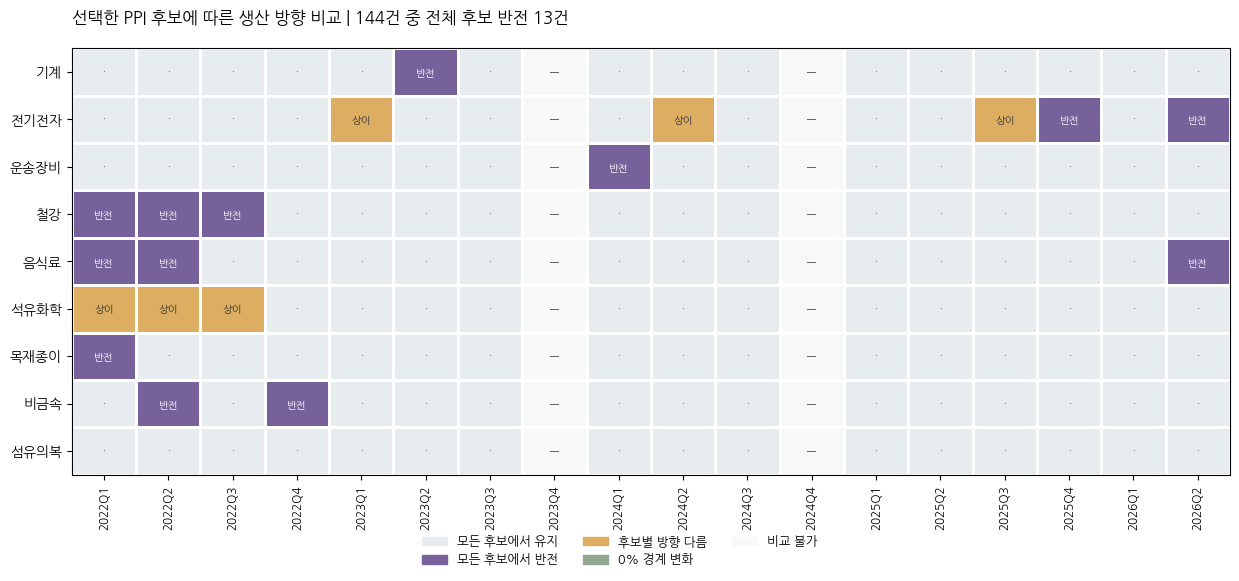

In [30]:
# 그림은 후보에 따라 해석이 달라지는 위치를 보여준다.
IND_PPI=[i for i in IND_ORDER_EMP if i in set(sig.industry)]
PPI_STATUS=['모든 후보에서 유지','모든 후보에서 반전','후보별 방향 다름','0% 경계 변화','비교 불가']
PPI_COLORS=['#E7ECEF','#76619A','#DDAE62','#93A891','#F8F8F8']
ppi_codes={s:i for i,s in enumerate(PPI_STATUS)}
ppi_pivot=sig.pivot(index='industry',columns='quarter',values='status').reindex(index=IND_PPI,columns=QUARTERS).fillna('비교 불가')
ppi_arr=ppi_pivot.apply(lambda col: col.map(ppi_codes)).to_numpy()
fig,ax=plt.subplots(figsize=(12.5,5.5))
ax.pcolormesh(ppi_arr,cmap=ListedColormap(PPI_COLORS),norm=BoundaryNorm(np.arange(-.5,5.5),5),edgecolors='white',linewidth=.8)
for ri in range(len(IND_PPI)):
    for qi in range(len(QUARTERS)):
        value=ppi_arr[ri,qi]
        label={0:'·',1:'반전',2:'상이',3:'0%',4:'—'}[value]
        ax.text(qi+.5,ri+.5,label,ha='center',va='center',fontsize=7.5,color='white' if value==1 else '#333333')
ax.set_xticks(np.arange(len(QUARTERS))+.5,QUARTERS,rotation=90,fontsize=8.5)
ax.set_yticks(np.arange(len(IND_PPI))+.5,IND_PPI,fontsize=10)
ax.invert_yaxis()
r=results_summary['ppi']
ax.set_title(f'선택한 PPI 후보에 따른 생산 방향 비교 | {r["n_comparable"]}건 중 전체 후보 반전 {r["n_opposite"]}건',loc='left',pad=18)
fig.legend([Rectangle((0,0),1,1,color=x) for x in PPI_COLORS],PPI_STATUS,
    loc='lower center',ncol=3,frameon=False,bbox_to_anchor=(.5,-.06),fontsize=9)
plt.tight_layout()
save_fig(fig,'V1_PPI_후보별_방향비교');plt.show()

In [31]:
ppi_display_names={'quarter':'분기','industry':'업종','state':'명목국면','production_yoy':'명목생산YoY(%)',
    'employment_yoy':'고용YoY(%)','ppi_items':'사용후보','ppi_lo':'PPI변화율_최소(%)','ppi_hi':'PPI변화율_최대(%)',
    'adjusted_lo':'조정YoY_최소(%)','adjusted_hi':'조정YoY_최대(%)','status':'후보별방향','adjusted_state':'조정기준국면'}
display(sig.loc[sig.different,['quarter','industry','state','production_yoy','ppi_items',
    'ppi_lo','ppi_hi','adjusted_lo','adjusted_hi','status','adjusted_state']].rename(columns=ppi_display_names).round(2))
print(f'{LATEST} 후보별 결과 (최솟값~최댓값은 선택한 후보 결과의 범위):')
display(latest_sig[['production_yoy','employment_yoy','ppi_items','adjusted_lo','adjusted_hi','status','adjusted_state']].rename(columns=ppi_display_names).round(2))
display(ppi_map[['industry','C1','ppi_item','mapping_use','main_analysis_eligible','sensitivity_eligible','mapping_reason']].rename(columns={
    'industry':'업종','C1':'항목코드','ppi_item':'후보항목','mapping_use':'사용범위','main_analysis_eligible':'본분석사용',
    'sensitivity_eligible':'민감도사용','mapping_reason':'선택근거와제약'}))

2026Q2 후보별 결과 (최솟값~최댓값은 선택한 후보 결과의 범위):


,분기,업종,명목국면,명목생산YoY(%),사용후보,PPI변화율_최소(%),PPI변화율_최대(%),조정YoY_최소(%),조정YoY_최대(%),후보별방향,조정기준국면
1,2022Q1,목재종이,S1,10.39,목재및종이제품,15.02,15.02,-4.02,-4.02,모든 후보에서 반전,S3
3,2022Q1,석유화학,S1,23.23,석탄및석유제품; 화학제품,15.63,63.56,-24.66,6.57,후보별 방향 다름,후보별 상이
6,2022Q1,음식료,S1,3.90,음식료품,5.63,5.63,-1.64,-1.64,모든 후보에서 반전,S3
8,2022Q1,철강,S1,32.27,철강1차제품,36.02,36.02,-2.76,-2.76,모든 후보에서 반전,S3
11,2022Q2,비금속,S2,5.28,비금속광물제품,12.49,12.49,-6.41,-6.41,모든 후보에서 반전,S4
12,2022Q2,석유화학,S1,33.09,석탄및석유제품; 화학제품,15.32,81.99,-26.87,15.41,후보별 방향 다름,후보별 상이
15,2022Q2,음식료,S1,4.57,음식료품,8.08,8.08,-3.25,-3.25,모든 후보에서 반전,S3
17,2022Q2,철강,S1,26.84,철강1차제품,30.22,30.22,-2.59,-2.59,모든 후보에서 반전,S3
21,2022Q3,석유화학,S1,21.39,석탄및석유제품; 화학제품,11.16,55.12,-21.74,9.20,후보별 방향 다름,후보별 상이
26,2022Q3,철강,S1,9.16,철강1차제품,10.49,10.49,-1.20,-1.20,모든 후보에서 반전,S3


,명목생산YoY(%),고용YoY(%),사용후보,조정YoY_최소(%),조정YoY_최대(%),후보별방향,조정기준국면
industry,,,,,,,
기계,-19.55,-6.34,기계및장비,-20.55,-20.55,모든 후보에서 유지,S4
목재종이,-12.90,-10.08,목재및종이제품,-15.29,-15.29,모든 후보에서 유지,S4
비금속,45.67,-1.08,비금속광물제품,40.86,40.86,모든 후보에서 유지,S2
석유화학,-6.73,9.56,석탄및석유제품; 화학제품,-45.54,-21.72,모든 후보에서 유지,S3
섬유의복,-12.32,0.00,섬유및의복,-15.17,-15.17,모든 후보에서 유지,N
운송장비,19.64,-0.78,운송장비,17.24,17.24,모든 후보에서 유지,S2
음식료,0.87,-3.79,음식료품,-0.78,-0.78,모든 후보에서 반전,S4
전기전자,2.70,-0.41,전기장비; 컴퓨터전자및광학기기,-15.11,-5.17,모든 후보에서 반전,S4
철강,32.65,-1.14,철강1차제품,25.28,25.28,모든 후보에서 유지,S2


,업종,항목코드,후보항목,사용범위,본분석사용,민감도사용,선택근거와제약
0,기계,13102134604ACC_CD.311AA,기계및장비,sensitivity_only,False,True,분류가 가까운 단일 후보
1,운송장비,13102134604ACC_CD.312AA,운송장비,sensitivity_only,False,True,전국 운송장비 전체 후보; 산단 품목 비중 미확인
2,비금속,13102134604ACC_CD.306AA,비금속광물제품,sensitivity_only,False,True,분류가 가까운 단일 후보
3,음식료,13102134604ACC_CD.301AA,음식료품,sensitivity_only,False,True,분류가 가까운 단일 후보
4,목재종이,13102134604ACC_CD.303AA,목재및종이제품,sensitivity_only,False,True,분류가 가까운 단일 후보
5,섬유의복,13102134604ACC_CD.3021AA,섬유및의복,sensitivity_only,False,True,가죽을 포함하는 상위 항목 대신 하위 후보
6,철강,13102134604ACC_CD.3071AA,철강1차제품,sensitivity_only,False,True,비철금속을 포함하는 상위 지수 대신 철강 후보; 가공품 구성 미확인
7,석유화학,13102134604ACC_CD.304AA,석탄및석유제품,sensitivity_only,False,True,품목별 가중치 없이 두 후보를 각각 적용
8,석유화학,13102134604ACC_CD.305AA,화학제품,sensitivity_only,False,True,품목별 가중치 없이 두 후보를 각각 적용
9,전기전자,13102134604ACC_CD.309AA,컴퓨터전자및광학기기,sensitivity_only,False,True,품목별 가중치 없이 두 후보를 각각 적용


In [32]:
r=results_summary['ppi']
first_year=ppi_year.index.min()
a=ppi_year.loc[first_year]; b=ppi_year.drop(first_year)
other_n=int(b.관측수.sum());other_diff=int(b.차이관측.sum())
other_pct=other_diff/other_n*100 if other_n else float('nan')
display(Markdown(f"""### PPI 재계산 결과

- 원자료: {r['month_start']}~{r['month_end']}, {r['n_months']}개월. {r['raw_names']}개 항목명에 {r['raw_series']}개 코드 계열이 있다.
  같은 이름이 여러 계층에 있어 **항목명만으로 선택하지 않았다**. 전체 원자료 중 기간이 짧은 계열은 {r['raw_incomplete_series']}개이며 사용 후보에는 포함하지 않았다.
- 사용 후보: {r['selected_series']}계열, 월 결측 {r['selected_missing_months']}건. 모두 같은 기준연도다.
  초기 YoY는 {r['first_yoy_quarter']}부터 계산된다. 전체 원자료의 다른 기준연도 항목: {r['raw_other_units']}. 사용 후보와는 구분한다.
- 비교 가능: {r['n_quarters']}분기 × {r['n_industries']}업종의 {r['n_comparable']}건.
  매핑 대상 중 생산·고용 YoY가 있는 {r['n_target']}건 대비 {r['coverage_pct']:.1f}%다. **관측치 포함률이며 매핑 정확도가 아니다.**
- 명목과 다른 방향이 가능한 관측 {r['n_different']}건 중 **모든 후보에서 반전 {r['n_opposite']}건**,
  **후보에 따라 양·음이 달라지는 경우 {r['n_candidate_dependent']}건**, 0% 경계 변화 {r['n_zero_boundary']}건이다.
- {first_year}년 차이 관측은 {int(a.차이관측)}/{int(a.관측수)}건({a['차이비율%']:.1f}%),
  나머지 기간은 {other_diff}/{other_n}건({other_pct:.1f}%)이다. 기간별 기술 비교이며 원인을 검증한 결과가 아니다.

### 두 고용비중의 정확한 의미

{LATEST} 동일한 비교 대상에서 고용 감소·명목 생산 증가 업종의 고용 합은 **{r['nominal_numerator']:,.0f}명**,
고용 감소·모든 PPI 후보에서 조정 생산 증가인 업종의 고용 합은 **{r['adjusted_numerator']:,.0f}명**이다.
분모는 둘 다 제조업 전체 **{r['employment_denominator']:,.0f}명**이므로 각각
**{r['nominal_share_pct']:.1f}%**, **{r['adjusted_share_pct']:.1f}%**다.

PPI 결과는 {', '.join(r['adjusted_up_industries']) or '해당 없음'}에서 모든 후보가 양수다.
최신분기 고용 감소 업종 중 비교하지 못한 업종: {', '.join(r['latest_uncompared_down']) or '없음'}.
이 비중은 고용 감소 관측 중 생산 증가의 **건수 비율**과 다르며, 실제 일자리 감소분의 비중도 아니다.

선택한 후보 결과가 같아도 다른 모든 매핑에서 같다고 일반화하지 않는다. 본분석 국면은 명목 기준을 유지한다.
"""))

### PPI 재계산 결과

- 원자료: 2021-01~2026-06, 66개월. 426개 항목명에 526개 코드 계열이 있다.
  같은 이름이 여러 계층에 있어 **항목명만으로 선택하지 않았다**. 전체 원자료 중 기간이 짧은 계열은 1개이며 사용 후보에는 포함하지 않았다.
- 사용 후보: 11계열, 월 결측 0건. 모두 같은 기준연도다.
  초기 YoY는 2022Q1부터 계산된다. 전체 원자료의 다른 기준연도 항목: [{'C1_NM': '정제혼합용원료유', 'UNIT_NM': '2025.12＝100'}]. 사용 후보와는 구분한다.
- 비교 가능: 16분기 × 9업종의 144건.
  매핑 대상 중 생산·고용 YoY가 있는 144건 대비 100.0%다. **관측치 포함률이며 매핑 정확도가 아니다.**
- 명목과 다른 방향이 가능한 관측 19건 중 **모든 후보에서 반전 13건**,
  **후보에 따라 양·음이 달라지는 경우 6건**, 0% 경계 변화 0건이다.
- 2022년 차이 관측은 11/36건(30.6%),
  나머지 기간은 8/108건(7.4%)이다. 기간별 기술 비교이며 원인을 검증한 결과가 아니다.

### 두 고용비중의 정확한 의미

2026Q2 동일한 비교 대상에서 고용 감소·명목 생산 증가 업종의 고용 합은 **54,794명**,
고용 감소·모든 PPI 후보에서 조정 생산 증가인 업종의 고용 합은 **26,180명**이다.
분모는 둘 다 제조업 전체 **114,830명**이므로 각각
**47.7%**, **22.8%**다.

PPI 결과는 비금속, 운송장비, 철강에서 모든 후보가 양수다.
최신분기 고용 감소 업종 중 비교하지 못한 업종: 없음.
이 비중은 고용 감소 관측 중 생산 증가의 **건수 비율**과 다르며, 실제 일자리 감소분의 비중도 아니다.

선택한 후보 결과가 같아도 다른 모든 매핑에서 같다고 일반화하지 않는다. 본분석 국면은 명목 기준을 유지한다.


### EIS — 서로 다른 범위의 고용 흐름

KICOX 산단 제조업 고용과 EIS 창원시 제조업 피보험자를 전년동기 대비 방향으로 함께 확인한다.
분기말 인원 자료로 계산하며, 월별 흐름 전체를 확보한 것으로 간주하지 않는다.
수준값을 합산하거나 한 통계를 다른 통계의 정확성 검증 기준으로 쓰지 않는다.

         eis_manufacturing_yoy_pct  kicox_mfg_yoy   부호일치
quarter                                                 
2023Q1                        1.33          -3.04  False
2023Q2                        1.27          -2.99  False
2023Q3                        2.11          -1.89  False
2023Q4                        2.55           1.05   True
2024Q1                        1.41           0.24   True
2024Q2                        1.80           2.59   True
2024Q3                        1.22           2.59   True
2024Q4                        0.70           0.94   True
2025Q1                        0.66           2.56   True
2025Q2                       -0.16           2.46  False
2025Q3                        0.11           0.17   True
2025Q4                        0.46           0.76   True
2026Q1                        0.44          -1.68  False
2026Q2                        0.67          -3.64  False

부호가 일치한 분기: 8 / 14
2026Q2: KICOX -3.6% vs EIS +0.7%
두 지표는 모집단·정의가 달라 수준·점유율을 계산하지 않으며, 

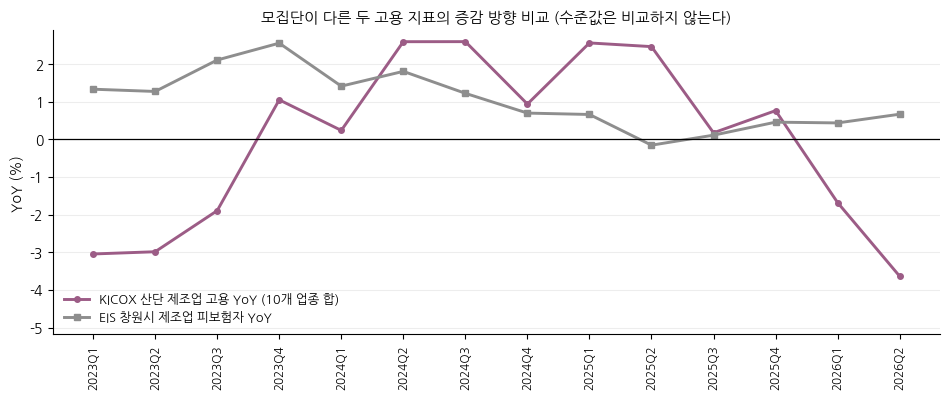

In [33]:
eis_proc_path=DIR_PROC/'eis/eis_validation_panel.csv'
eis_raw_path=ROOT/'data/raw/eis/eis_changwon_insured_2022M03_2026M06.csv'
if eis_proc_path.is_file():
    eis=pd.read_csv(eis_proc_path)
    record_input(eis_proc_path,'기존 EIS 검증 패널')
else:
    eis=pd.read_csv(eis_raw_path,comment='#').sort_values('quarter')
    record_input(eis_raw_path,'공유된 EIS 분기말 인원')
    assert not eis.quarter.duplicated().any()
    es=eis.set_index(pd.PeriodIndex(eis.quarter,freq='Q')).changwon_manufacturing
    es=es.reindex(pd.period_range(es.index.min(),es.index.max(),freq='Q'))
    eis_yoy=(es/es.shift(4)-1)*100
    eis=pd.DataFrame({'quarter':es.index.astype(str),'eis_manufacturing_yoy_pct':eis_yoy.values})
# KICOX는 패널 내부 lag4 합계를 사용해 첫 분석연도의 값을 잃지 않는다.
mfg_yoy=mfg.mfg_emp_delta/lag_mfg*100
merged = (eis[['quarter', 'eis_manufacturing_yoy_pct']]
          .merge(mfg_yoy.rename('kicox_mfg_yoy').reset_index(), on='quarter', how='inner').dropna())

fig, ax = plt.subplots(figsize=(9.6, 4.1))
x = np.arange(len(merged))
ax.plot(x, merged.kicox_mfg_yoy, color=SERIES_COLORS['employment'], lw=2.1, marker='o', ms=4,
        label='KICOX 산단 제조업 고용 YoY (10개 업종 합)')
ax.plot(x, merged.eis_manufacturing_yoy_pct, color='#8E8E8E', lw=2.1, marker='s', ms=4,
        label='EIS 창원시 제조업 피보험자 YoY')
ax.axhline(0, color='black', lw=0.9)
ax.set_xticks(x); ax.set_xticklabels(merged.quarter, rotation=90, fontsize=8.5)
ax.set_ylabel('YoY (%)', fontsize=10.2)
_lo, _hi = ax.get_ylim()
ax.set_ylim(_lo - (_hi - _lo) * 0.18, _hi)     # 좌하단 범례가 선을 가리지 않도록 여백
ax.set_title('모집단이 다른 두 고용 지표의 증감 방향 비교 (수준값은 비교하지 않는다)', fontsize=11)
ax.legend(loc='lower left', frameon=False, fontsize=9)
style_ax(ax)
plt.tight_layout()
save_fig(fig, 'V2_EIS_YoY비교')
plt.show()

merged['부호일치'] = np.sign(merged.kicox_mfg_yoy) == np.sign(merged.eis_manufacturing_yoy_pct)
print(merged.set_index('quarter').round(2).to_string())
print()
print(f'부호가 일치한 분기: {int(merged.부호일치.sum())} / {len(merged)}')
print(f'{merged.quarter.iloc[-1]}: KICOX {merged.kicox_mfg_yoy.iloc[-1]:+.1f}% vs '
      f'EIS {merged.eis_manufacturing_yoy_pct.iloc[-1]:+.1f}%')
print('두 지표는 모집단·정의가 달라 수준·점유율을 계산하지 않으며, 차이의 원인도 판단할 수 없다.')
results_summary['eis']={'n_comparable':len(merged),'n_same':int(merged.부호일치.sum()),
    'start':merged.quarter.min(),'end':merged.quarter.max()}

## Section 7. 업종별 진단카드

상태·규모·시간과 보조지표를 함께 읽는다. 숫자는 앞에서 계산한 표를 재사용한다.
N은 한 지표 이상 변화율이 0%인 경우이며, S1~S4 지속기간 집계에서 제외한다.

In [34]:
cur = state[state.quarter == LATEST].set_index('industry')
card = pd.DataFrame({
    '현재국면': cur.state,
    '생산YoY%': cur.production_yoy,
    '고용YoY%': cur.employment_yoy,
    '고용(명)': cur.employment,
    '고용증감(명)': cur.emp_delta,
    '고용비중%': cur.employment / cur.employment.sum() * 100,
    '현재지속(Q)': cur.run_length,
    '최장지속(Q)': longest.지속분기,
    '최장국면': longest.국면,
    '가동률%': cur.op_rate_official,
    '가동률YoY(%p)': cur.op_rate_official_yoy_pp,
    '입주업체': cur.firms_in,
    '입주YoY%': cur.firms_in_yoy,
    '가동업체': cur.firms_op,
    '가동YoY%': cur.firms_op_yoy,
}).reindex(IND_ORDER_EMP)
if usable:
    card.insert(6, '기여율%', q2['기여율%'].reindex(IND_ORDER_EMP))
card['최근경로(6Q)'] = [state_path(i, 6, '→') for i in card.index]
card.index = [f'{i} ★' if i in MAIN_IND else i for i in card.index]

print(f'업종별 진단카드 ({LATEST} 기준, ★ = Q2에서 선별한 주요 업종)')
print(card.drop(columns=['최근경로(6Q)']).round(2).to_string())
print()
print('최근 6분기 국면 경로:')
for i, p in card['최근경로(6Q)'].items():
    print(f'  {i:9s} {p}')
card.to_csv(DIR_TAB / f'업종별_진단카드_{LATEST}.csv', encoding='utf-8-sig')
print()
print(f'-> outputs/tables/업종별_진단카드_{LATEST}.csv 저장')

업종별 진단카드 (2026Q2 기준, ★ = Q2에서 선별한 주요 업종)
       현재국면  생산YoY%  고용YoY%    고용(명)  고용증감(명)  고용비중%   기여율%  현재지속(Q)  최장지속(Q) 최장국면   가동률%  가동률YoY(%p)    입주업체  입주YoY%    가동업체  가동YoY%
기계 ★     S4  -19.55   -6.34  58784.0  -3979.0  51.19  91.85      2.0      3.0   S2  80.61       -4.89  1556.0    1.37  1458.0    0.34
전기전자 ★   S2    2.70   -0.41  27979.0   -116.0  24.37   2.68      1.0      3.0   S1  76.65       -0.38   651.0    1.88   590.0    3.33
운송장비 ★   S2   19.64   -0.78  16308.0   -129.0  14.20   2.98      2.0      4.0   S1  92.28        0.97   254.0    0.79   245.0    0.41
철강 ★     S2   32.65   -1.14   9689.0   -112.0   8.44   2.59      4.0      4.0   S2  63.68        0.24    80.0    1.27    74.0   -1.33
음식료      S2    0.87   -3.79    635.0    -25.0   0.55   0.58      2.0      7.0   S1  92.30       -1.43     7.0    0.00     4.0    0.00
석유화학     S3   -6.73    9.56    619.0     54.0   0.54  -1.25      1.0      7.0   S1  76.31       -3.32    49.0    8.89    45.0    9.76
목재종이     S4  -12.90  

In [35]:
for ind in MAIN_IND:
    r=card.loc[ind] if ind in card.index else card.loc[f'{ind} ★']
    length_text='집계 제외' if pd.isna(r['현재지속(Q)']) else f"{int(r['현재지속(Q)'])}분기째"
    p=latest_sig.loc[ind] if ind in latest_sig.index else None
    ppi_text='PPI 비교 불가' if p is None else (
        f"선택 후보 조정값 {p.adjusted_lo:+.2f}%~{p.adjusted_hi:+.2f}% · {p.status}")
    display(Markdown(f"""### {ind}

**직접 확인:** {LATEST} 명목 생산 {r['생산YoY%']:+.1f}%, 고용 {r['고용YoY%']:+.1f}% → {r['현재국면']}.
고용 {r['고용(명)']:,.0f}명, 전년동기 증감 {r['고용증감(명)']:+,.0f}명, 고용비중 {r['고용비중%']:.1f}%.
현재 상태는 {length_text}. 최근 경로: {r['최근경로(6Q)']}.

**보조 확인:** {ppi_text}. 본분석 국면은 바꾸지 않는다.

**해석 가능:** 현재 방향뿐 아니라 변화 인원과 연속 관측기간을 함께 확인할 수 있다.

**판단 불가:** 기업별 채용·감원, 자동화·외주화·인력부족의 영향, 집계 변경 여부, 향후 국면과 정책효과.
"""))

### 기계

**직접 확인:** 2026Q2 명목 생산 -19.5%, 고용 -6.3% → S4.
고용 58,784명, 전년동기 증감 -3,979명, 고용비중 51.2%.
현재 상태는 2분기째. 최근 경로: S1→S1→S3→S1→S4→S4.

**보조 확인:** 선택 후보 조정값 -20.55%~-20.55% · 모든 후보에서 유지. 본분석 국면은 바꾸지 않는다.

**해석 가능:** 현재 방향뿐 아니라 변화 인원과 연속 관측기간을 함께 확인할 수 있다.

**판단 불가:** 기업별 채용·감원, 자동화·외주화·인력부족의 영향, 집계 변경 여부, 향후 국면과 정책효과.


### 전기전자

**직접 확인:** 2026Q2 명목 생산 +2.7%, 고용 -0.4% → S2.
고용 27,979명, 전년동기 증감 -116명, 고용비중 24.4%.
현재 상태는 1분기째. 최근 경로: S2→S4→S4→S2→S4→S2.

**보조 확인:** 선택 후보 조정값 -15.11%~-5.17% · 모든 후보에서 반전. 본분석 국면은 바꾸지 않는다.

**해석 가능:** 현재 방향뿐 아니라 변화 인원과 연속 관측기간을 함께 확인할 수 있다.

**판단 불가:** 기업별 채용·감원, 자동화·외주화·인력부족의 영향, 집계 변경 여부, 향후 국면과 정책효과.


### 운송장비

**직접 확인:** 2026Q2 명목 생산 +19.6%, 고용 -0.8% → S2.
고용 16,308명, 전년동기 증감 -129명, 고용비중 14.2%.
현재 상태는 2분기째. 최근 경로: S2→S4→S2→S4→S2→S2.

**보조 확인:** 선택 후보 조정값 +17.24%~+17.24% · 모든 후보에서 유지. 본분석 국면은 바꾸지 않는다.

**해석 가능:** 현재 방향뿐 아니라 변화 인원과 연속 관측기간을 함께 확인할 수 있다.

**판단 불가:** 기업별 채용·감원, 자동화·외주화·인력부족의 영향, 집계 변경 여부, 향후 국면과 정책효과.


### 철강

**직접 확인:** 2026Q2 명목 생산 +32.6%, 고용 -1.1% → S2.
고용 9,689명, 전년동기 증감 -112명, 고용비중 8.4%.
현재 상태는 4분기째. 최근 경로: S3→S1→S2→S2→S2→S2.

**보조 확인:** 선택 후보 조정값 +25.28%~+25.28% · 모든 후보에서 유지. 본분석 국면은 바꾸지 않는다.

**해석 가능:** 현재 방향뿐 아니라 변화 인원과 연속 관측기간을 함께 확인할 수 있다.

**판단 불가:** 기업별 채용·감원, 자동화·외주화·인력부족의 영향, 집계 변경 여부, 향후 국면과 정책효과.


## Section 8. 핵심 결과와 해석상 주의점

In [ ]:
h=results_summary['q1_history'];q1=results_summary['q1_latest'];q2r=results_summary['q2'];q3r=results_summary['q3'];p=results_summary['ppi']
report_text=f"""# EDA 수정 및 재실행 결과

## 1. 최종 결정

| 결정사항 | 최종 결정 | 핵심 이유 |
|---|---|---|
| PPI 매핑 | 선택한 후보에 한정한 민감도 분석 | 전국·산단 품목 구성과 가중치 대응 미확인 |
| PPI 본분석 사용 | 사용하지 않음 | 대체 시 추가 가정이 큼 |
| S1~S4 판정 | 명목 생산 YoY와 고용 YoY | 동일한 공개통계 기준 유지 |
| 명목 생산 | 본분석 상태·지속·전환의 기준 | 실제 물량과 구분 |
| PPI 조정 생산 | 가격지수 후보별 보조 비교 | 실제 생산량·생산성으로 해석하지 않음 |
| confirmed | 제거 | 승인 대기와 분석 적합성을 혼동하지 않음 |
| aux_usable | sensitivity_eligible로 대체 | 계산 가능한 후보에 한해 민감도 분석 허용 |

## 2. PPI 재계산

원자료 {p['month_start']}~{p['month_end']}의 {p['n_months']}개월, 사용 {p['selected_series']}계열의 월 결측은 {p['selected_missing_months']}건이다.
{p['raw_names']}개 항목명과 {p['raw_series']}개 코드가 있어 코드·통계표·측정항목으로 선택했다.
전체 원자료에서 기간이 짧은 계열은 {p['raw_incomplete_series']}개이며 선택 후보에는 없다.
분기 PPI는 세 달이 모두 있을 때의 산술평균, YoY는 달력상 전년동기 대비다. 첫 YoY는 {p['first_yoy_quarter']}다.

비교 {p['n_comparable']}건, 명목과 다른 방향이 가능한 관측 {p['n_different']}건({p['different_pct']:.1f}%)이다.
이 중 모든 후보에서 반전은 {p['n_opposite']}건, 후보별 양·음이 달라지는 경우는 {p['n_candidate_dependent']}건이다.
전체 후보 반전과 후보별 방향 차이는 구분해 해석한다.

{markdown_table(ppi_year.round(2))}

{LATEST} 고용 감소·명목 생산 증가 업종 고용 합 {p['nominal_numerator']:,.0f}명을 제조업 전체 {p['employment_denominator']:,.0f}명으로 나누면 {p['nominal_share_pct']:.1f}%다.
동일한 분모에서 모든 후보의 조정 생산이 증가한 업종 고용 합 {p['adjusted_numerator']:,.0f}명은 {p['adjusted_share_pct']:.1f}%다.
이는 감소 인원 비중이나 업종 수 비율이 아니다.

{markdown_table(latest_sig[['production_yoy','adjusted_lo','adjusted_hi','status']].rename(columns=ppi_display_names).round(2))}


## 3. 핵심 결과

| 질문 | 직접 확인 | 해석 범위 | 판단 불가 |
|---|---|---|---|
| Q1 상태 | 고용 감소 {h['n_down']}건 중 명목 생산 증가 {h['n_up_down']}건({h['simple_pct']:.1f}%) | 같은 고용 방향에서도 생산액 방향은 다를 수 있음 | 불일치의 원인 |
| Q2 규모 | {LATEST} 제조업 고용 전년동기 증감 {q2r['net_delta']:+,.0f}명, 최대 감소 {', '.join(q2r['largest_decrease_industries'])} | 증감률과 인원을 함께 읽음 | 실제 채용·감원·재분류별 인원 |
| Q3 시간 | 연속구간 {q3r['n_runs']}개, 두 분기 이상 {q3r['share_2plus_pct']:.1f}%, 인접 유지 {q3r['n_same']}/{q3r['n_adjacent']}건 | 관측된 연속·전환 요약 | 미래 국면·실제 완료 지속기간 |

## 4. 보고서용 PPI 문안

생산실적은 금액 자료이므로 생산 방향의 해석이 가격지수 선택에 따라 달라지는지 확인하였다.
본분석은 KICOX 명목 생산액과 고용의 전년동기 대비 변화 방향을 유지하고, 업종별 PPI 후보를 적용한 결과는 보조적으로 비교하였다.
비교 가능한 {p['n_comparable']}개 업종·분기 관측 중 {p['n_opposite']}개는 선택한 모든 후보에서 생산 방향이 명목 기준과 반대였고,
{p['n_candidate_dependent']}개는 후보에 따라 증가·감소가 달라졌다.

PPI는 전국 국내 출하가격을 반영하며, 창원국가산단 업종의 품목 구성과 내수·수출 비중이 같다고 확인되지 않았다.
따라서 조정값을 실제 생산량으로 해석하거나 기존 국면을 대체하지 않았다.
이 결과는 선택한 가격지수에 따라 생산 방향의 설명이 달라질 수 있는 업종·분기를 보여주는 자료로 활용하였다.


방법론 근거: [한국은행 물가지수 설명](https://www.bok.or.kr/portal/bbs/B0000216/view.do?menuNo=200134&nttId=165633&pageIndex=).
"""
final_summary_text = f"""### Q1·Q2·Q3 요약

| 질문 | 이번 계산에서 확인한 것 | 해석 범위 |
|---|---|---|
| Q1 상태 | 고용 감소 {h['n_down']}건 중 명목 생산 증가 {h['n_up_down']}건({h['simple_pct']:.1f}%) | 같은 고용 방향에서도 생산액 방향은 다를 수 있다. |
| Q2 규모 | {LATEST} 고용 전년동기 증감 {q2r['net_delta']:+,.0f}명, 최대 감소 {', '.join(q2r['largest_decrease_industries'])} | 증감률과 인원 규모를 함께 읽는다. |
| Q3 시간 | 최장 관측 {q3r['max_run']}분기, 인접 유지 {q3r['n_same']}/{q3r['n_adjacent']}건({q3r['same_pct']:.1f}%) | 관측된 지속·전환이며 실제 전체 기간이나 미래 확률이 아니다. |

PPI 비교 {p['n_comparable']}건 중 모든 후보에서 반전 {p['n_opposite']}건, 후보별 방향 차이 {p['n_candidate_dependent']}건이다.
본분석은 명목 기준을 유지한다. 자동화·인력부족·정책효과 등 원인은 이 자료만으로 확인할 수 없다.
"""
display(Markdown(final_summary_text))
(DIR_REPORT/'EDA_revision_report.md').write_text(report_text,encoding='utf-8')
(DIR_TAB/'results_summary.json').write_text(json.dumps(results_summary,ensure_ascii=False,indent=2,allow_nan=False),encoding='utf-8')
pd.DataFrame(input_audit).to_csv(DIR_TAB/'input_provenance.csv',index=False,encoding='utf-8-sig')
verification_scope.to_csv(DIR_TAB/'verification_scope.csv',index=False,encoding='utf-8-sig')

### Q1·Q2·Q3 요약

| 질문 | 이번 계산에서 확인한 것 | 해석 범위 |
|---|---|---|
| Q1 상태 | 고용 감소 89건 중 명목 생산 증가 43건(48.3%) | 같은 고용 방향에서도 생산액 방향은 다를 수 있다. |
| Q2 규모 | 2026Q2 고용 전년동기 증감 -4,332명, 최대 감소 기계 | 증감률과 인원 규모를 함께 읽는다. |
| Q3 시간 | 최장 관측 7분기, 인접 유지 88/130건(67.7%) | 관측된 지속·전환이며 실제 전체 기간이나 미래 확률이 아니다. |

PPI 비교 144건 중 모든 후보에서 반전 13건, 후보별 방향 차이 6건이다.
본분석은 명목 기준을 유지한다. 자동화·인력부족·정책효과 등 원인은 이 자료만으로 확인할 수 없다.


### 해석할 때 지킬 기준

- 국면은 명목 금액과 고용의 방향 분류이며 업종의 우열을 나타내지 않는다.
- PPI 후보별 결과는 산단 실제 가격·물량의 보장된 범위가 아니다.
- 전환 빈도는 과거 인접 관측의 비율이며 예측확률이 아니다.
- 관측기간 시작·끝과 결측 구간 때문에 실제 지속기간 전체는 확정할 수 없다.
- 데이터가 바뀌면 결과표·차트·f-string 문구를 함께 다시 실행한다. 별도 검증을 완료하지 못한 자료는 검증 완료로 표시하지 않는다.